In [1]:
#using python3.10 for torch to work properly
#use environment.yml
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
import os

# Prévision du flux

## Dataset colonnes:

Données sur 

- station_id: identifiant unique station
- date: date
- year: année
- month: mois
- day: jour
- jour_semaine: jour de la semaine
- hour: heure 
- num_bikes_taken: nombre de vélos pris durant l'heure
- num_bikes_dropped: nombre de vélos déposés durant lh'eure
- net_flow: différence entre le nombre de vélos pris et déposé dans l'heure
- temp: témpérature à NYC à cette heure (°C)
- relative_humidity: humidité relative à NYC à cette heure (%)
- precipitation_total: précipitation totale à NYC durant cette heure (mm)
- snow_depth: profondeur de la neige à NYC durant cette heure (cm) -> supprimer ne contient pas de données
- average_wind_speed: moyenne du vent (km/h)
- sunshine_total: durée d'ensoleillement (min)  -> supprimer ne contient pas de données
- coco: code de condition métérologique:
                - Code	Weather Condition
                1	    Clear
                2	    Fair
                3	    Cloudy
                4	    Overcast
                5	    Fog
                6	    Freezing Fog
                7	    Light Rain
                8	    Rain
                9	    Heavy Rain
                10	    Freezing Rain
                11	    Heavy Freezing Rain
                12	    Sleet
                13	    Heavy Sleet
                14	    Light Snowfall
                15	    Snowfall
                16	    Heavy Snowfall
                17	    Rain Shower
                18	    Heavy Rain Shower
                19	    Sleet Shower
                20	    Heavy Sleet Shower
                21	    Snow Shower
                22	    Heavy Snow Shower
                23	    Lightning
                24	    Hail
                25	    Thunderstorm
                26	    Heavy Thunderstorm
                27	    Storm
- is_holiday: si le jour est férié (bool)

## EDA


### Charger et inspecter les données

- Taille du dataset (rows, colonnes)
- Types de variables
- Aperçu (head, tail, sample)
- Détection d’erreurs évidentes

In [ ]:
#Charger données
PATH = "/Users/pierre-yvesbenevise/Documents/DataEngineer/Projects/citibike_prediction/01_Data/"
dataset = pd.read_parquet(PATH + 'hourly_counts_all_stations.parquet')

In [3]:
dataset.info()
display(dataset.head())
display(dataset.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19674960 entries, 0 to 19674959
Data columns (total 17 columns):
 #   Column               Dtype         
---  ------               -----         
 0   station_id           category      
 1   date                 datetime64[ns]
 2   date_hour            datetime64[ns]
 3   year                 int32         
 4   month                int32         
 5   day                  int32         
 6   jour_semaine         category      
 7   hour                 int64         
 8   num_bikes_taken      int64         
 9   num_bikes_dropped    int64         
 10  net_flow             int64         
 11  temp                 float32       
 12  relative_humidity    float32       
 13  precipitation_total  float32       
 14  average_wind_speed   float32       
 15  coco                 int64         
 16  is_holiday           bool          
dtypes: bool(1), category(2), datetime64[ns](2), float32(4), int32(3), int64(5)
memory usage: 1.6 GB


,station_id,date,date_hour,year,month,day,jour_semaine,hour,num_bikes_taken,num_bikes_dropped,net_flow,temp,relative_humidity,precipitation_total,average_wind_speed,coco,is_holiday
0,2261.04,2024-11-01,2024-11-01 00:00:00,2024,11,1,Vendredi,0,0,0,0,23.0,52.0,0.0,7.000000,3,False
1,2261.04,2024-11-01,2024-11-01 01:00:00,2024,11,1,Vendredi,1,0,0,0,24.0,50.0,0.0,15.000000,3,False
2,2261.04,2024-11-01,2024-11-01 02:00:00,2024,11,1,Vendredi,2,0,0,0,23.0,52.0,0.0,7.000000,3,False
3,2261.04,2024-11-01,2024-11-01 03:00:00,2024,11,1,Vendredi,3,0,0,0,23.0,55.0,0.0,22.700001,3,False
4,2261.04,2024-11-01,2024-11-01 04:00:00,2024,11,1,Vendredi,4,0,0,0,22.0,55.0,0.0,11.000000,3,False


,station_id,date,date_hour,year,month,day,jour_semaine,hour,num_bikes_taken,num_bikes_dropped,net_flow,temp,relative_humidity,precipitation_total,average_wind_speed,coco,is_holiday
19674955,JC117,2025-10-31,2025-10-31 19:00:00,2025,10,31,Vendredi,19,0,0,0,14.0,42.0,0.0,29.900000,3,False
19674956,JC117,2025-10-31,2025-10-31 20:00:00,2025,10,31,Vendredi,20,0,0,0,13.0,47.0,0.0,31.299999,3,False
19674957,JC117,2025-10-31,2025-10-31 21:00:00,2025,10,31,Vendredi,21,0,0,0,13.0,45.0,0.0,13.000000,3,False
19674958,JC117,2025-10-31,2025-10-31 22:00:00,2025,10,31,Vendredi,22,0,0,0,13.0,45.0,0.0,7.000000,3,False
19674959,JC117,2025-10-31,2025-10-31 23:00:00,2025,10,31,Vendredi,23,0,0,0,13.0,41.0,0.0,24.000000,3,False


### Nettoyage initial

- Valeurs manquantes
- Types incorrects
- Doublons
- Incohérences

In [4]:
#Pourcentage de vide
print('Pourcentage de vide')
missing_pct = 100 * dataset.isnull().sum() / dataset.shape[0]
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print(missing_pct)

Pourcentage de vide
Series([], dtype: float64)


-> Pas de valeurs manquantes

In [5]:
#Examiner les colonnes catégorielles
for col in dataset.select_dtypes(include="object"):
    print(col, dataset[col].nunique(), dataset[col].unique())

-> 1 seule variable catégorielle: station_id

In [6]:
dups = dataset[dataset.duplicated(subset=["station_id", "date_hour"], keep=False)]
print('Couple sation_id et date_hour en double', dups.shape[0])

Couple sation_id et date_hour en double 0


-> il n'y a pas de données en double

In [7]:
print(
    'Même nombre de dates par station_id :',
    dataset.groupby('station_id', observed=True)['date_hour']
           .nunique()
           .nunique()
)

Même nombre de dates par station_id : 1


-> toutes les stations ont le même nombre de dates

In [8]:
date_sets = dataset.groupby('station_id', observed=True)['date_hour'].apply(set)

all_equal = date_sets.apply(lambda x: x == date_sets.iloc[0]).all()

print(all_equal)

True


-> toutes les stations ont exactement le même date

### Statistiques descriptives

- Moyenne, médiane, variance
- Distribution des variables
- Fréquences (variables catégorielles)

In [9]:
col_numeric = dataset.select_dtypes(include=["int32","int64",'float32', "float64"]).columns.tolist()
print('Colonnes numériques:', col_numeric)

dataset[col_numeric].describe().T

Colonnes numériques: ['year', 'month', 'day', 'hour', 'num_bikes_taken', 'num_bikes_dropped', 'net_flow', 'temp', 'relative_humidity', 'precipitation_total', 'average_wind_speed', 'coco']


,count,mean,std,min,25%,50%,75%,max
year,19674960.0,2024.832877,0.373086,2024.0,2025.00,2025.0,2025.00,2025.0
month,19674960.0,6.526027,3.447851,1.0,4.00,7.0,10.00,12.0
day,19674960.0,15.720548,8.796247,1.0,8.00,16.0,23.00,31.0
hour,19674960.0,11.500000,6.922187,0.0,5.75,11.5,17.25,23.0
num_bikes_taken,19674960.0,2.191938,4.608805,0.0,0.00,0.0,2.00,197.0
num_bikes_dropped,19674960.0,2.191980,4.666943,0.0,0.00,0.0,2.00,193.0
net_flow,19674960.0,0.000043,2.791945,-134.0,-1.00,0.0,0.00,101.0
temp,19674960.0,13.348401,9.729108,-12.0,6.00,14.0,21.00,37.0
relative_humidity,19674960.0,59.481133,19.623020,13.0,44.00,58.0,76.00,100.0
precipitation_total,19674960.0,0.068630,0.421779,0.0,0.00,0.0,0.00,10.5


Il n'y a pas l'air d'avoir des valeurs abérrantes et les variables de dates et celles métérologiques ont l'air dans une amplitute correcte. 

Les variations du flux net sont très importantes.

In [10]:
col_weather = ["temp","relative_humidity", "precipitation_total",  "average_wind_speed"]
col_velo = ["num_bikes_taken", "num_bikes_dropped", "net_flow"]

### Analyse univariée

Analyse variable par variable :

- Histogrammes
- Boxplots
- Bar charts

Détecter :

- skewness
- valeurs extrêmes
- distribution globale

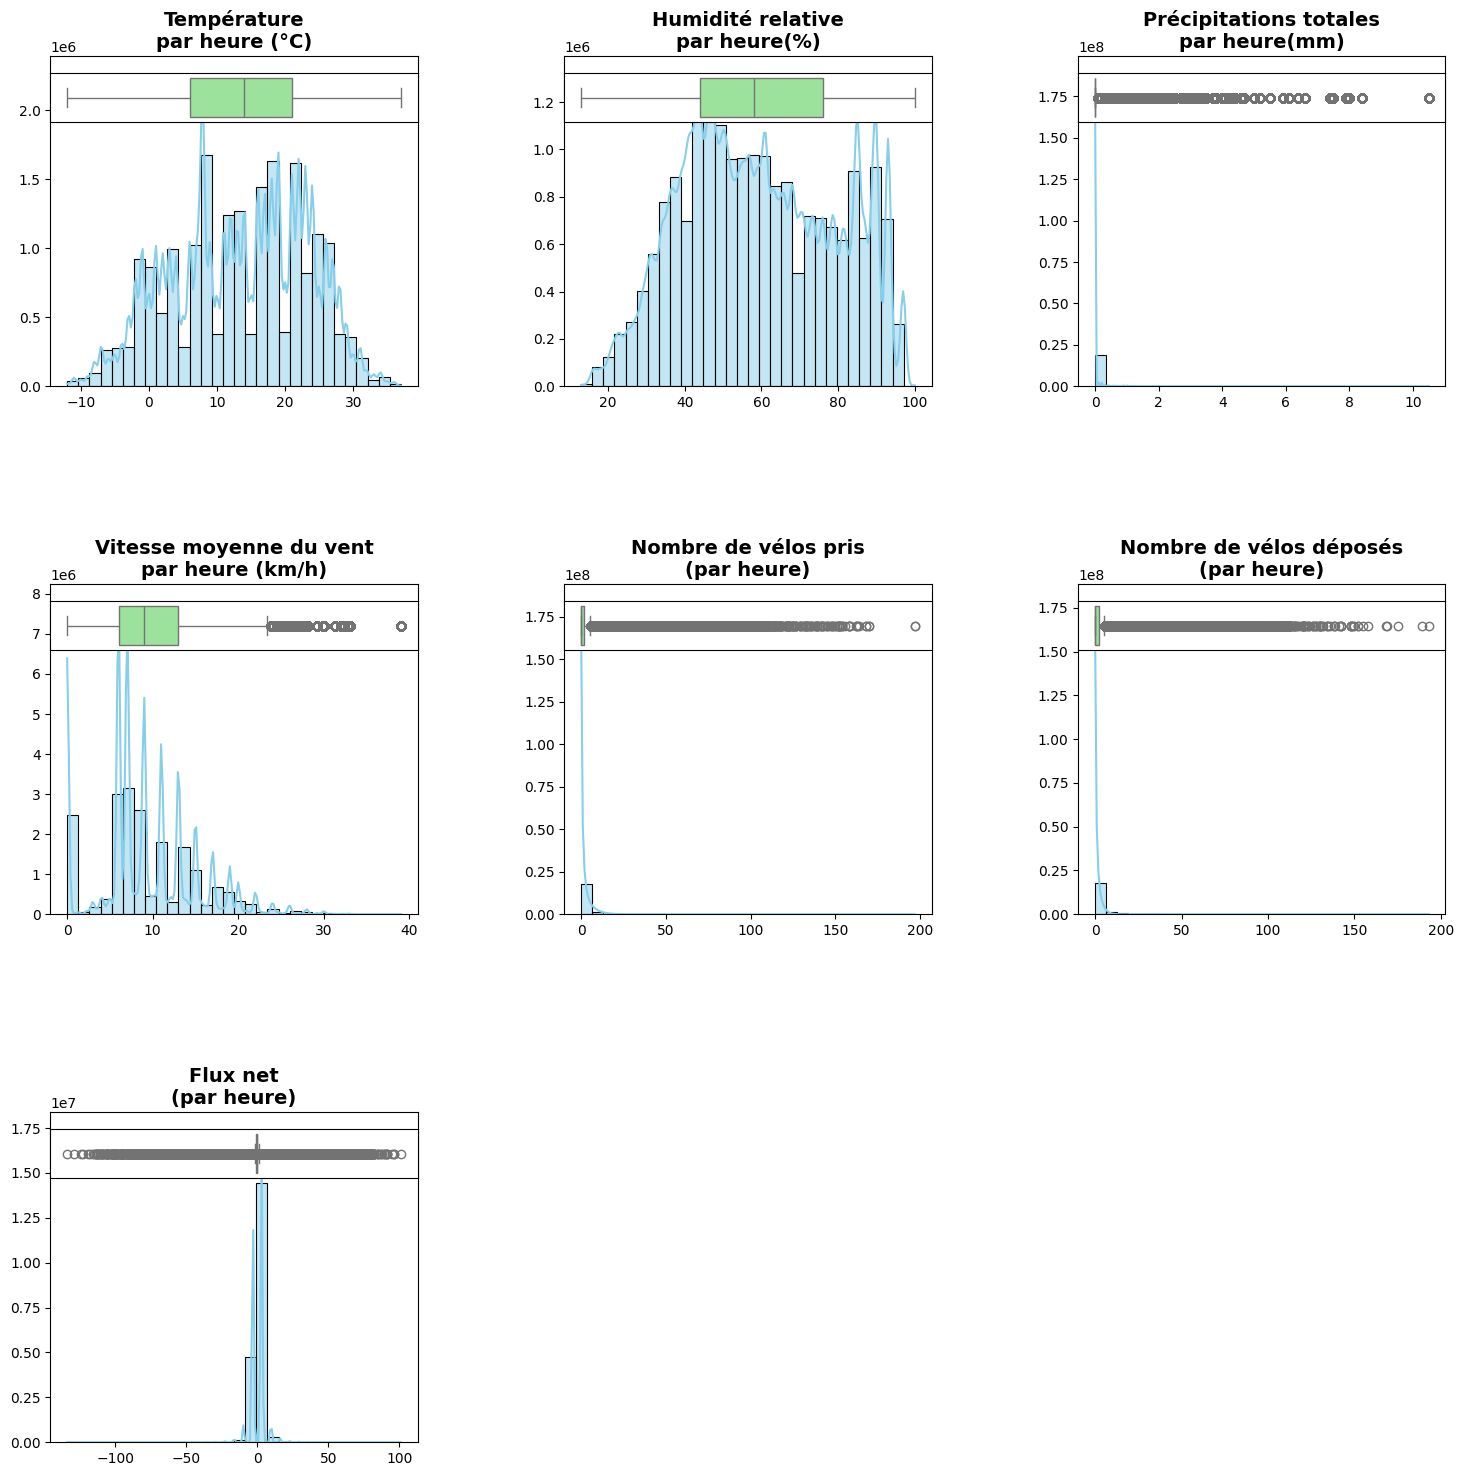

In [11]:
col_numeric = col_weather + col_velo
# Visualisation des distributions des variables numériques avec histogrammes et boxplots
# Dictionnaire titres
titles_dict = {
    "temp": "Température\npar heure (°C)",
    "relative_humidity": "Humidité relative\npar heure(%)",
    "precipitation_total": "Précipitations totales\npar heure(mm)",
    "average_wind_speed": "Vitesse moyenne du vent\npar heure (km/h)",
    "num_bikes_taken": "Nombre de vélos pris\n(par heure)",
    "num_bikes_dropped": "Nombre de vélos déposés\n(par heure)",
    "net_flow": "Flux net\n(par heure)",
}

n_cols = 3
n_rows = len(col_numeric) // n_cols + (len(col_numeric) % n_cols > 0)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*6))
fig.subplots_adjust(hspace=0.6, wspace=0.4)

axes = axes.flatten()

for i, col in enumerate(col_numeric):
    ax_hist = axes[i]

    # Boxplot au-dessus de l'histogramme
    ax_box = ax_hist.inset_axes([0, 0.8, 1, 0.15])
    sns.boxplot(x=dataset[col], ax=ax_box, color='lightgreen')
    ax_box.set_xticks([])       # supprimer ticks x
    ax_box.set_yticks([])       # supprimer ticks y
    ax_box.set_xlabel('')       # supprimer label x
    ax_box.set_ylabel('')       # supprimer label y

    # Histogramme principal
    sns.histplot(dataset[col], bins=30, kde=True, ax=ax_hist, color='skyblue')
    ax_hist.set_xlabel('')  # supprimer label x
    ax_hist.set_ylabel('')  # supprimer label y

    # Titre personnalisé depuis le dict si disponible
    title = titles_dict.get(col, col)
    ax_hist.set_title(title, fontsize=14, fontweight='bold')

    # Ajuster y max pour un peu d'espace
    y_max = ax_hist.get_ylim()[1]
    ax_hist.set_ylim(0, y_max*1.1)

# Supprimer axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

-> données précipitations n'ont pas l'air très importantes

-> grosses disparités au niveau du nbre de vélos pris, déposés et donc du flux 

In [12]:
col_categorical = ['is_holiday', 'coco_label']
print('Colonnes catégorielles:', col_categorical)

Colonnes catégorielles: ['is_holiday', 'coco_label']


In [13]:
# Mapping for coco values
coco_map = {
    1: "Ciel dégagé - 1",
    2: "Temps clair - 2",
    3: "Nuageux - 3",
    4: "Ciel couvert - 4",
    5: "Brouillard - 5",
    6: "Brouillard givrant - 6",
    7: "Pluie légère - 7",
    8: "Pluie - 8",
    9: "Pluie forte - 9",
    10: "Pluie verglaçante - 10",
    11: "Pluie verglaçante forte - 11",
    12: "Grésil - 12",
    13: "Grêle forte - 13",
    14: "Chutes de neige légères - 14",
    15: "Chutes de neige - 15",
    16: "Fortes chutes de neige - 16",
    17: "Averse de pluie - 17",
    18: "Fortes averses de pluie - 18",
    19: "Averse de grésil - 19",
    20: "Fortes averses de grésil - 20",
    21: "Averse de neige - 21",
    22: "Fortes averses de neige - 22",
    23: "Foudre - 23",
    24: "Grêle - 24",
    25: "Orage - 25",
    26: "Fort orage - 26",
    27: "Tempête - 27"
}

# Apply mapping
dataset['coco_label'] = dataset['coco'].map(coco_map)

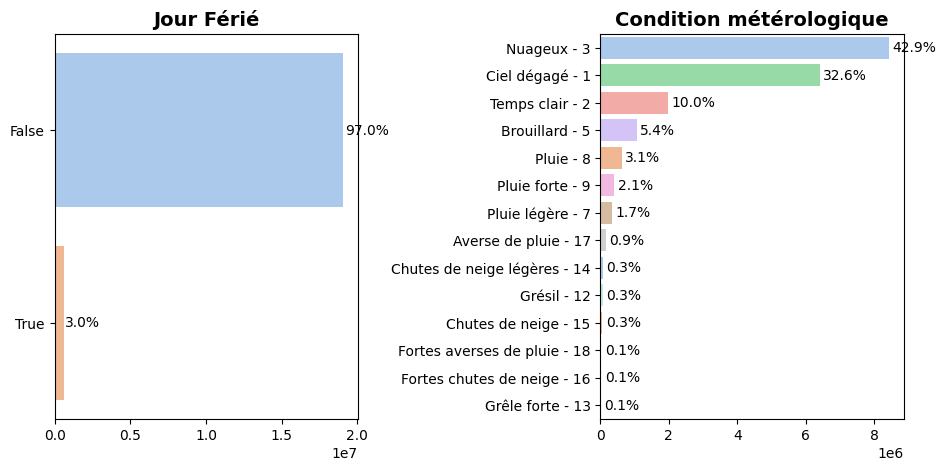

In [14]:
# Visualisation des distributions des variables catégorielles avec des barplots
# Dictionnaire titres
titles_dict_cat = {
    "is_holiday": "Jour Férié",
    "coco_label": "Condition métérologique",
}

n_cols = 3
n_rows = len(col_categorical) // n_cols + (len(col_categorical) % n_cols > 0)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*5))
fig.subplots_adjust(hspace=0.9, wspace=0.8)
axes = axes.flatten()

for i, col in enumerate(col_categorical):
    ax = axes[i]

    # Countplot horizontal
    sns.countplot(
        y=col,
        data=dataset,
        ax=ax,
        hue=col,       # nécessaire pour palette
        palette='pastel',
        order=dataset[col].value_counts().index,
        dodge=False,   # empile toutes les barres
        legend=False
    )

    # Supprimer labels axes
    ax.set_xlabel('')
    ax.set_ylabel('')

    # Titre
    ax.set_title(titles_dict_cat[col], fontsize=14, fontweight='bold')

    # Ajouter pourcentages sur chaque barre
    total = len(dataset)
    for p in ax.patches:
        width = p.get_width()
        percentage = width / total * 100
        ax.text(width + total*0.005,  # un petit décalage
                p.get_y() + p.get_height()/2,
                f'{percentage:.1f}%',
                va='center')

# Supprimer axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

- 1    Ciel dégagé
- 2    Temps clair
- 3    Nuageux
- 4    Ciel couvert
- 5    Brouillard
- 6    Brouillard givrant
- 7    Pluie légère
- 8    Pluie
- 9    Pluie forte
- 10    Pluie verglaçante
- 11    Pluie verglaçante forte
- 12    Grésil
- 13    Grêle forte
- 14    Chutes de neige légères
- 15    Chutes de neige
- 16    Fortes chutes de neige
- 17    Averse de pluie
- 18    Fortes averses de pluie
- 19    Averse de grésil
- 20    Fortes averses de grésil
- 21    Averse de neige
- 22    Fortes averses de neige
- 23    Foudre
- 24    Grêle
- 25    Orage
- 26    Fort orage
- 27    Tempête

-> condition métérologique seule 3,1% ont de la pluie (coco = 8)

est-ce normal?

est-ce que cela est intéressant d'utiliser condition météorologique pour prédire les flux de vélos?

peut être n'utiliser que les témpératures et l'humidité?

A discuter avec Sébastien:
    -> pourquoi pas ne regrouper coco en moins de catégorie:
        - beau temps
        - temps humide
        - temps horrible

In [15]:
#nombre de stations_id uniques
num_stations = dataset['station_id'].nunique()
print('Nombre de stations uniques :', num_stations) 

Nombre de stations uniques : 2246


In [16]:
# Stations avec le plus de vélos pris
top_stations_taken = (
    dataset
    .groupby('station_id', observed=True)[['num_bikes_taken']]
    .sum()
    .sort_values(by='num_bikes_taken', ascending=False)
    .head(20)
    .reset_index()
)
print('Stations avec le plus de vélos pris :')
print(top_stations_taken)
print('\n')
top_stations_taken_avg = (
    dataset
    .groupby(['station_id','date'], observed=True)['num_bikes_taken']
    .sum()
    .groupby('station_id', observed=True)
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
print('Stations avec le plus de vélos pris en moyenne par jour:')
print(top_stations_taken_avg)

Stations avec le plus de vélos pris :
   station_id  num_bikes_taken
0     6140.05           161958
1     5788.13           142223
2     6233.04           137477
3     6331.01           133161
4     5905.12           130691
5     6492.08           129157
6     5905.14           128048
7     6726.01           125877
8     6948.10           121389
9     5980.10           118004
10    5779.11           116385
11    5492.05           114377
12    6173.08           114160
13    6450.05           114102
14    6364.07           113649
15    6459.07           112724
16    6197.08           112037
17    5374.01           109740
18    6072.06           106621
19    6098.10           106349


Stations avec le plus de vélos pris en moyenne par jour:
   station_id  num_bikes_taken
0     6140.05       443.720548
1     5788.13       389.652055
2     6233.04       376.649315
3     6331.01       364.824658
4     5905.12       358.057534
5     6492.08       353.854795
6     5905.14       350.816438
7   

In [17]:
# Stations avec le plus de vélos déposés
top_stations_dropped = (
    dataset
    .groupby(['station_id'], observed=True)['num_bikes_dropped']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
print('Stations avec le plus de vélos déposés :')
print(top_stations_dropped)
print('\n')
top_stations_dropped_avg = (
    dataset
    .groupby(['station_id','date'], observed=True)['num_bikes_dropped']
    .sum()
    .groupby('station_id', observed=True)
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
print('Stations avec le plus de vélos déposés en moyenne par jour:')
print(top_stations_dropped_avg)

Stations avec le plus de vélos déposés :
   station_id  num_bikes_dropped
0     6140.05             162915
1     5788.13             143262
2     6233.04             137147
3     6331.01             133537
4     5905.14             129442
5     6492.08             129398
6     5905.12             129344
7     6726.01             126039
8     6948.10             119858
9     5980.10             119468
10    6450.05             115667
11    5779.11             115109
12    6173.08             114878
13    5492.05             114403
14    6364.07             113477
15    6197.08             113153
16    6459.07             111971
17    5374.01             111591
18    6072.06             108727
19    6098.10             106800


Stations avec le plus de vélos déposés en moyenne par jour:
   station_id  num_bikes_dropped
0     6140.05         446.342466
1     5788.13         392.498630
2     6233.04         375.745205
3     6331.01         365.854795
4     5905.14         354.635616
5     

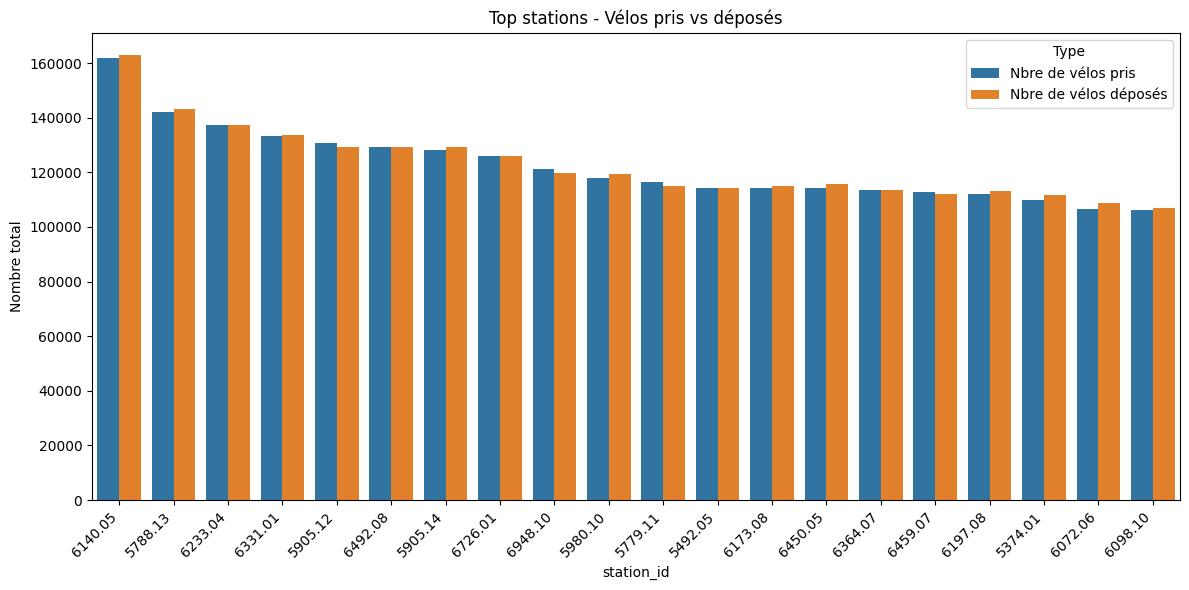

Stations présentes à la fois dans le top des stations avec le plus de vélos pris et déposés :
['6140.05', '5788.13', '6233.04', '6331.01', '5905.12', '6492.08', '5905.14', '6726.01', '6948.10', '5980.10', '5779.11', '5492.05', '6173.08', '6450.05', '6364.07', '6459.07', '6197.08', '5374.01', '6072.06', '6098.10']


In [18]:
#Identifier les stations qui sont à la fois dans le top des déposés et pris
    
df_compare = top_stations_taken.merge(
    top_stations_dropped,
    on='station_id',
    how='outer'
)

# Format long pour seaborn
df_plot = df_compare.melt(
    id_vars='station_id',
    value_vars=['num_bikes_taken', 'num_bikes_dropped'],
    var_name='Type',
    value_name='Nombre'
)

# Trier par nombre de vélos pris
df_compare = df_compare.sort_values(
    by='num_bikes_taken',
    ascending=False
)

station_order = df_compare['station_id']

# Renommer les types
df_plot['Type'] = df_plot['Type'].map({
    'num_bikes_taken': 'Nbre de vélos pris',
    'num_bikes_dropped': 'Nbre de vélos déposés'
})

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_plot,
    x='station_id',
    y='Nombre',
    hue='Type',
    order=station_order,
    dodge=True
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Nombre total')
plt.title('Top stations - Vélos pris vs déposés')
plt.legend(title='Type')
plt.tight_layout()
plt.show()


top_taken_dropped = df_compare['station_id'].tolist()
print('Stations présentes à la fois dans le top des stations avec le plus de vélos pris et déposés :')
print(list(top_taken_dropped))


In [19]:
#Stations qui ont le plus de flux net positif (plus de vélos pris que déposés)
top_stations_net_flow_positive = (
    dataset
    .groupby(['station_id'], observed=True)['net_flow']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
print('Stations avec le plus de flux net positif (plus de vélos pris que déposés) :')

print(top_stations_net_flow_positive)
print('\n')
top_stations_net_flow_positive_avg = (
    dataset
    .groupby(['station_id',], observed=True)['net_flow']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)
print('Stations avec le plus de flux net positif en moyenne (plus de vélos pris que déposés) :')
print(top_stations_net_flow_positive_avg)

Stations avec le plus de flux net positif (plus de vélos pris que déposés) :
   station_id  net_flow
0     5411.08      3807
1     5730.08      3387
2     6072.06      2106
3     5593.01      1983
4     5721.14      1881
5     5374.01      1851
6     5470.10      1817
7     5669.10      1776
8     4095.03      1666
9     6839.15      1658
10    5669.12      1646
11    5569.06      1645
12    5659.05      1614
13    5712.12      1587
14    6450.05      1565
15    4013.08      1544
16    3834.10      1534
17    5847.08      1531
18    4993.13      1517
19    6765.01      1504


Stations avec le plus de flux net positif en moyenne (plus de vélos pris que déposés) :
station_id
5411.08    0.434589
5730.08    0.386644
6072.06    0.240411
5593.01    0.226370
5721.14    0.214726
5374.01    0.211301
5470.10    0.207420
5669.10    0.202740
4095.03    0.190183
6839.15    0.189269
5669.12    0.187900
5569.06    0.187785
5659.05    0.184247
5712.12    0.181164
6450.05    0.178653
4013.08    0.17625

In [20]:
#Stations qui ont le plus de flux net négatif (plus de vélos déposés que pris)
top_stations_net_flow_negative = (
    dataset
    .groupby(['station_id'], observed=True)['net_flow']
    .sum()
    .sort_values(ascending=True)
    .head(20)
    .reset_index()
)
print('Stations avec le plus de flux net négatif (plus de vélos déposés que pris) :')

print(top_stations_net_flow_negative)
print('\n')
top_stations_net_flow_negative_avg = (
    dataset
    .groupby(['station_id',], observed=True)['net_flow']
    .mean()
    .sort_values(ascending=True)
    .head(20)
    .reset_index()
)
print('Stations avec le plus de flux net négatif en moyenne (plus de vélos déposés que pris) :')
print(top_stations_net_flow_negative_avg)

Stations avec le plus de flux net négatif (plus de vélos déposés que pris) :
   station_id  net_flow
0     6847.02     -4611
1     4010.01     -3808
2     3928.08     -3207
3     3919.07     -2910
4     6955.01     -2776
5     3984.02     -2691
6     6747.06     -2655
7     6912.01     -2634
8     7388.10     -2600
9     6072.11     -2530
10    6920.05     -2521
11    6379.03     -2450
12    6756.05     -2444
13    3902.06     -2346
14    4683.02     -2124
15    7014.12     -2082
16    6398.08     -1986
17    6890.06     -1975
18    5340.01     -1930
19    6089.07     -1907


Stations avec le plus de flux net négatif en moyenne (plus de vélos déposés que pris) :
   station_id  net_flow
0     6847.02 -0.526370
1     4010.01 -0.434703
2     3928.08 -0.366096
3     3919.07 -0.332192
4     6955.01 -0.316895
5     3984.02 -0.307192
6     6747.06 -0.303082
7     6912.01 -0.300685
8     7388.10 -0.296804
9     6072.11 -0.288813
10    6920.05 -0.287785
11    6379.03 -0.279680
12    6756.05 -0.

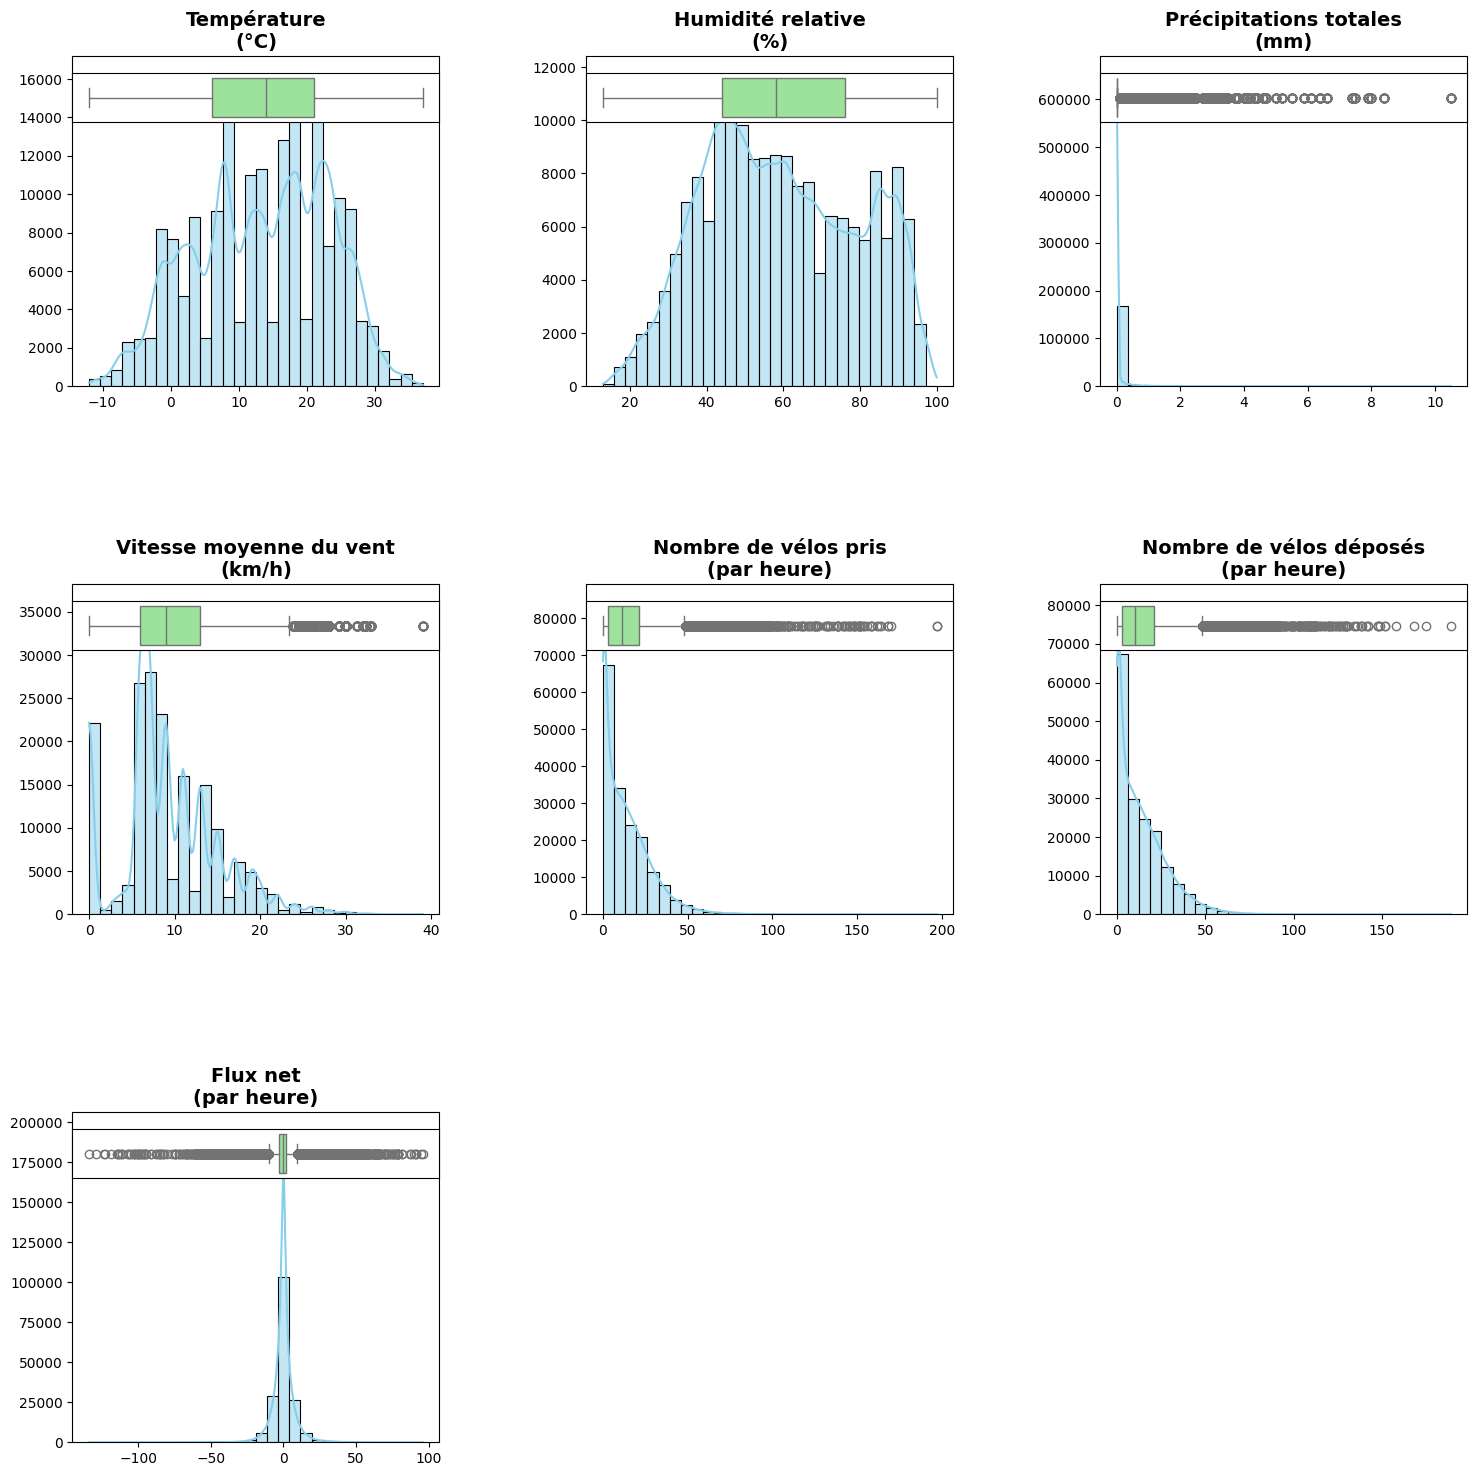

In [21]:
col_numeric = col_weather + col_velo
stations_in_both_str = [str(x) for x in top_taken_dropped]
filtered_data = dataset[dataset['station_id'].isin(stations_in_both_str)]

# Visualisation des distributions des variables numériques avec histogrammes et boxplots
# Dictionnaire titres
titles_dict = {
    "temp": "Température\n(°C)",
    "relative_humidity": "Humidité relative\n(%)",
    "precipitation_total": "Précipitations totales\n(mm)",
    "average_wind_speed": "Vitesse moyenne du vent\n(km/h)",
    "num_bikes_taken": "Nombre de vélos pris\n(par heure)",
    "num_bikes_dropped": "Nombre de vélos déposés\n(par heure)",
    "net_flow": "Flux net\n(par heure)",
}

n_cols = 3
n_rows = len(col_numeric) // n_cols + (len(col_numeric) % n_cols > 0)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*6))
fig.subplots_adjust(hspace=0.6, wspace=0.4)

axes = axes.flatten()

for i, col in enumerate(col_numeric):
    ax_hist = axes[i]

    # Boxplot au-dessus de l'histogramme
    ax_box = ax_hist.inset_axes([0, 0.8, 1, 0.15])
    sns.boxplot(x=filtered_data[col], ax=ax_box, color='lightgreen')
    ax_box.set_xticks([])       # supprimer ticks x
    ax_box.set_yticks([])       # supprimer ticks y
    ax_box.set_xlabel('')       # supprimer label x
    ax_box.set_ylabel('')       # supprimer label y

    # Histogramme principal
    sns.histplot(filtered_data[col], bins=30, kde=True, ax=ax_hist, color='skyblue')
    ax_hist.set_xlabel('')  # supprimer label x
    ax_hist.set_ylabel('')  # supprimer label y

    # Titre personnalisé depuis le dict si disponible
    title = titles_dict.get(col, col)
    ax_hist.set_title(title, fontsize=14, fontweight='bold')

    # Ajuster y max pour un peu d'espace
    y_max = ax_hist.get_ylim()[1]
    ax_hist.set_ylim(0, y_max*1.1)

# Supprimer axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

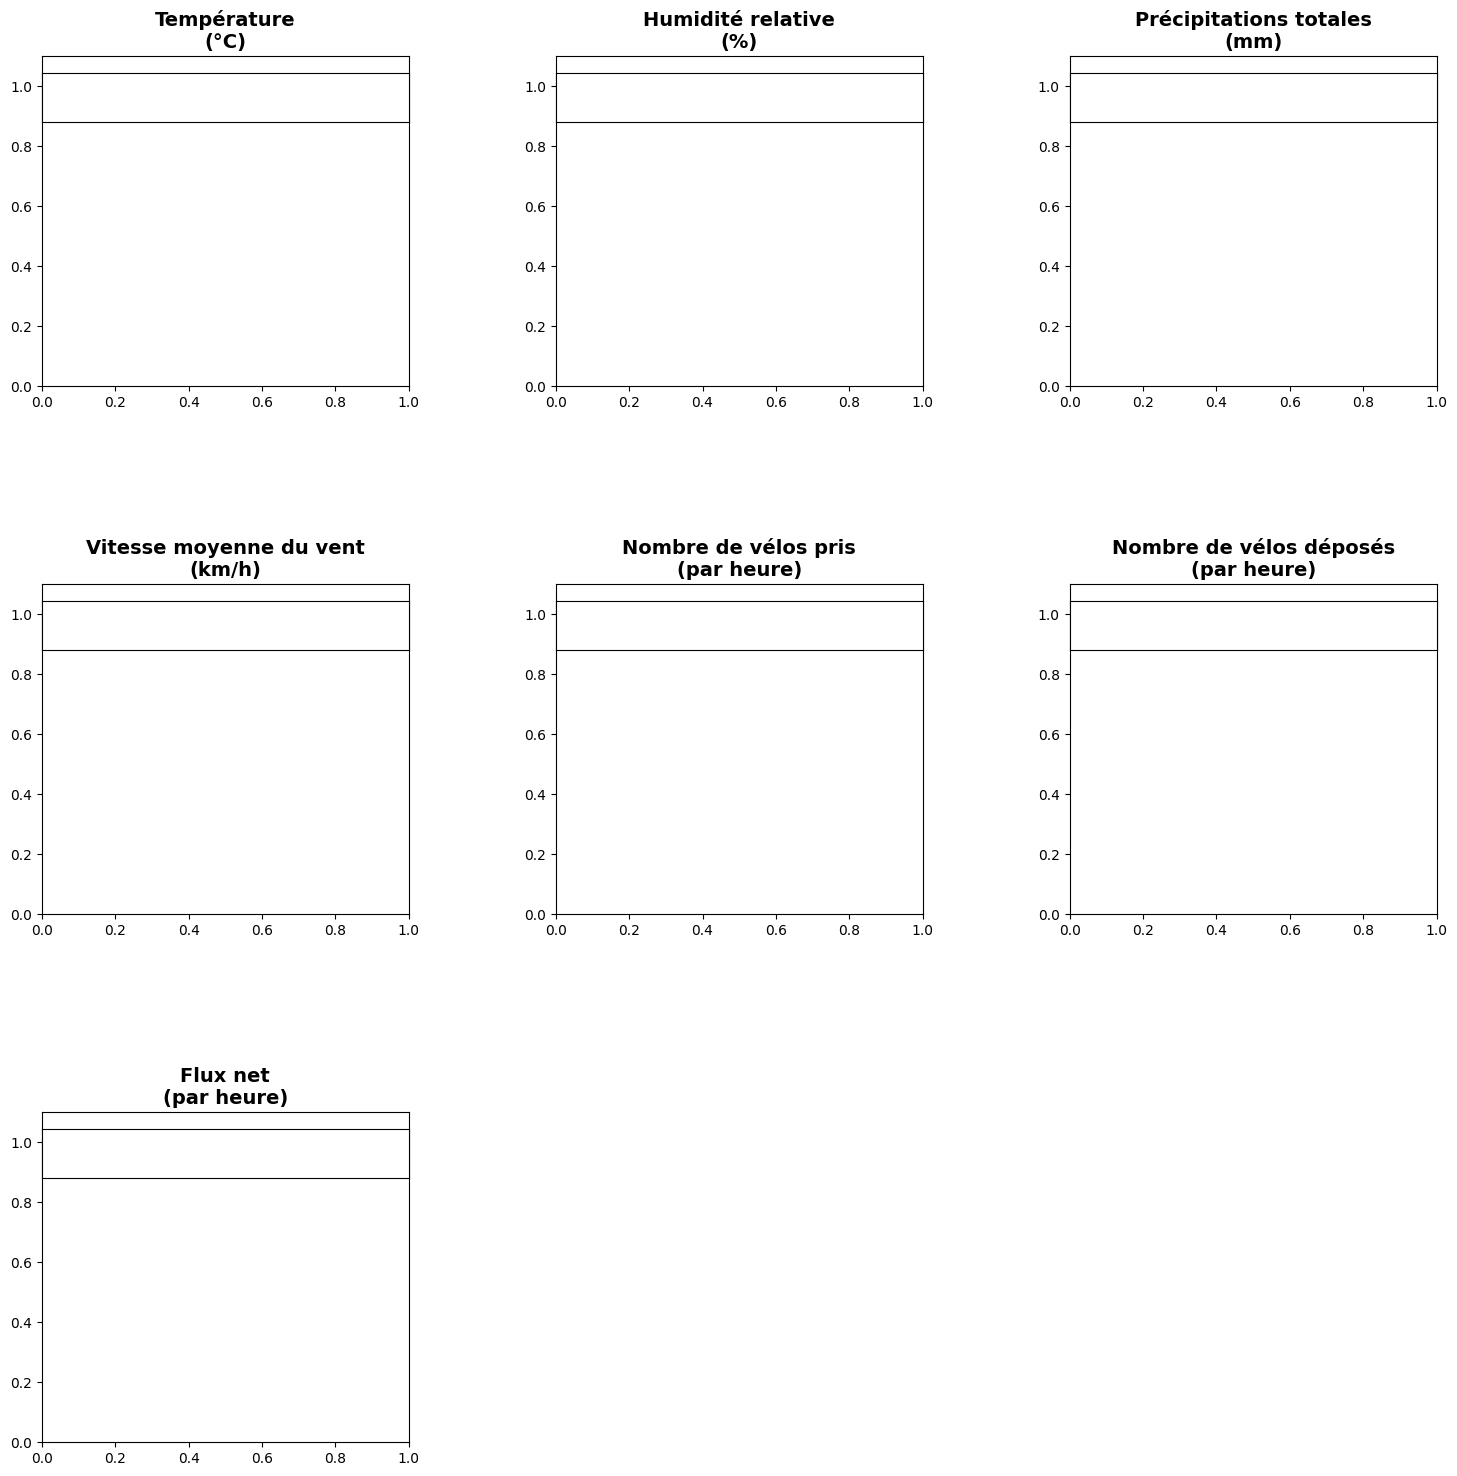

In [22]:
particular_stations = '5980.1'
col_numeric = col_weather + col_velo
filtered_data = dataset[dataset['station_id'] == particular_stations]

# Visualisation des distributions des variables numériques avec histogrammes et boxplots
# Dictionnaire titres
titles_dict = {
    "temp": "Température\n(°C)",
    "relative_humidity": "Humidité relative\n(%)",
    "precipitation_total": "Précipitations totales\n(mm)",
    "average_wind_speed": "Vitesse moyenne du vent\n(km/h)",
    "num_bikes_taken": "Nombre de vélos pris\n(par heure)",
    "num_bikes_dropped": "Nombre de vélos déposés\n(par heure)",
    "net_flow": "Flux net\n(par heure)",
}

n_cols = 3
n_rows = len(col_numeric) // n_cols + (len(col_numeric) % n_cols > 0)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*6))
fig.subplots_adjust(hspace=0.6, wspace=0.4)

axes = axes.flatten()

for i, col in enumerate(col_numeric):
    ax_hist = axes[i]

    # Boxplot au-dessus de l'histogramme
    ax_box = ax_hist.inset_axes([0, 0.8, 1, 0.15])
    sns.boxplot(x=filtered_data[col], ax=ax_box, color='lightgreen')
    ax_box.set_xticks([])       # supprimer ticks x
    ax_box.set_yticks([])       # supprimer ticks y
    ax_box.set_xlabel('')       # supprimer label x
    ax_box.set_ylabel('')       # supprimer label y

    # Histogramme principal
    sns.histplot(filtered_data[col], bins=30, kde=True, ax=ax_hist, color='skyblue')
    ax_hist.set_xlabel('')  # supprimer label x
    ax_hist.set_ylabel('')  # supprimer label y

    # Titre personnalisé depuis le dict si disponible
    title = titles_dict.get(col, col)
    ax_hist.set_title(title, fontsize=14, fontweight='bold')

    # Ajuster y max pour un peu d'espace
    y_max = ax_hist.get_ylim()[1]
    ax_hist.set_ylim(0, y_max*1.1)

# Supprimer axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

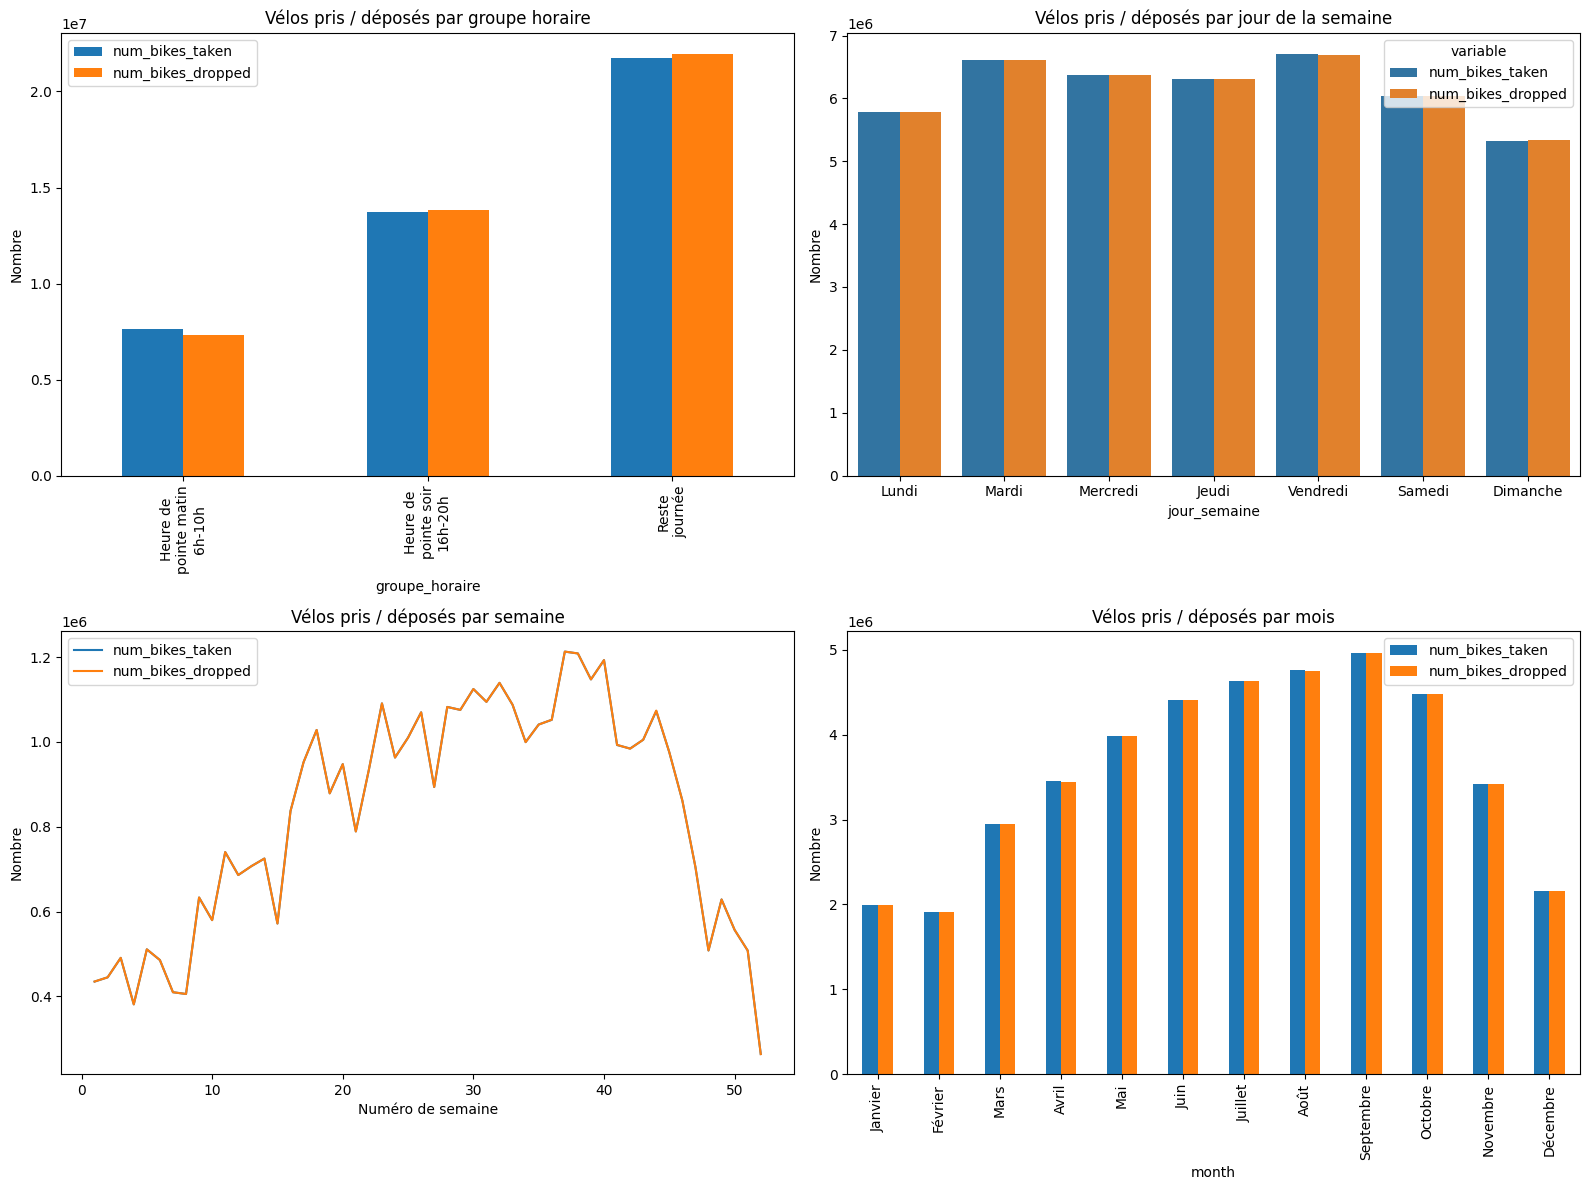

In [23]:
def tracer_flux_velos(dataset):
    """
    Trace num_bikes_taken, num_bikes_dropped
    agrégés par groupe horaire, jour de la semaine, semaine et mois.
    """
    dataset = dataset.copy()
    
    #  Par groupe horaire
    def groupe_horaire(hour):
        if 6 <= hour < 10:
            return 'Heure de\npointe matin\n6h-10h'
        elif 16 <= hour < 20:
            return 'Heure de\npointe soir\n16h-20h'
        else:
            return 'Reste\njournée'
    
    dataset['groupe_horaire'] = dataset['hour'].apply(groupe_horaire)
    agg_horaire = dataset.groupby('groupe_horaire')[['num_bikes_taken','num_bikes_dropped']].sum().reset_index()
    
    # par Jour de la semaine
    ordre_jours = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']
    agg_jour = (
        dataset
        .groupby('jour_semaine', observed=True)[['num_bikes_taken','num_bikes_dropped']]
        .sum()
        .reindex(ordre_jours)
        .reset_index()
    )        
    # Par semaine
    dataset['semaine'] = dataset['date'].dt.isocalendar().week
    agg_semaine = dataset.groupby('semaine')[['num_bikes_taken','num_bikes_dropped']].sum().reset_index()
    
    # Par mois
    ordre_mois = ['Janvier','Février','Mars','Avril','Mai','Juin','Juillet','Août','Septembre','Octobre','Novembre','Décembre']
    agg_mois = dataset.groupby('month')[['num_bikes_taken','num_bikes_dropped']].sum().reset_index()
    agg_mois['month'] = agg_mois['month'].map({1:'Janvier',2:'Février',3:'Mars',4:'Avril',5:'Mai',6:'Juin',7:'Juillet',8:'Août',9:'Septembre',10:'Octobre',11:'Novembre',12:'Décembre'})
    
    # Graph
    fig, axes = plt.subplots(2, 2, figsize=(16,12))
    
    # Groupe horaire
    agg_horaire.set_index('groupe_horaire').plot(kind='bar', ax=axes[0,0])
    axes[0,0].set_title('Vélos pris / déposés par groupe horaire')
    axes[0,0].set_ylabel('Nombre')
        
    # Jour de la semaine
    sns.barplot(
        data=agg_jour.melt(id_vars='jour_semaine'),
        x='jour_semaine', y='value', hue='variable', ax=axes[0,1]
    )
    axes[0,1].set_title('Vélos pris / déposés par jour de la semaine')
    axes[0,1].set_ylabel('Nombre')
    
    # Semaine
    agg_semaine.plot(x='semaine', y=['num_bikes_taken','num_bikes_dropped'], ax=axes[1,0])
    axes[1,0].set_title('Vélos pris / déposés par semaine')
    axes[1,0].set_xlabel('Numéro de semaine')
    axes[1,0].set_ylabel('Nombre')
    
    # Mois
    agg_mois.set_index('month').plot(kind='bar', ax=axes[1,1])
    axes[1,1].set_title('Vélos pris / déposés par mois')
    axes[1,1].set_ylabel('Nombre')
    
    plt.tight_layout()
    plt.show()

tracer_flux_velos(dataset)

Le jour de la semaine semble ne pas influencer de manière importante le nombre de vélos utilisés durant la journée.

Les mois les moins utilisés sont: Décembre, Janvier et Février.
Les mois les plutitilisés sont: September, Août, Juillet, Juin, Mai, Octobre. Très clairemenent les conditions métérologiques sont à prendre en compte dans l'analyse.   

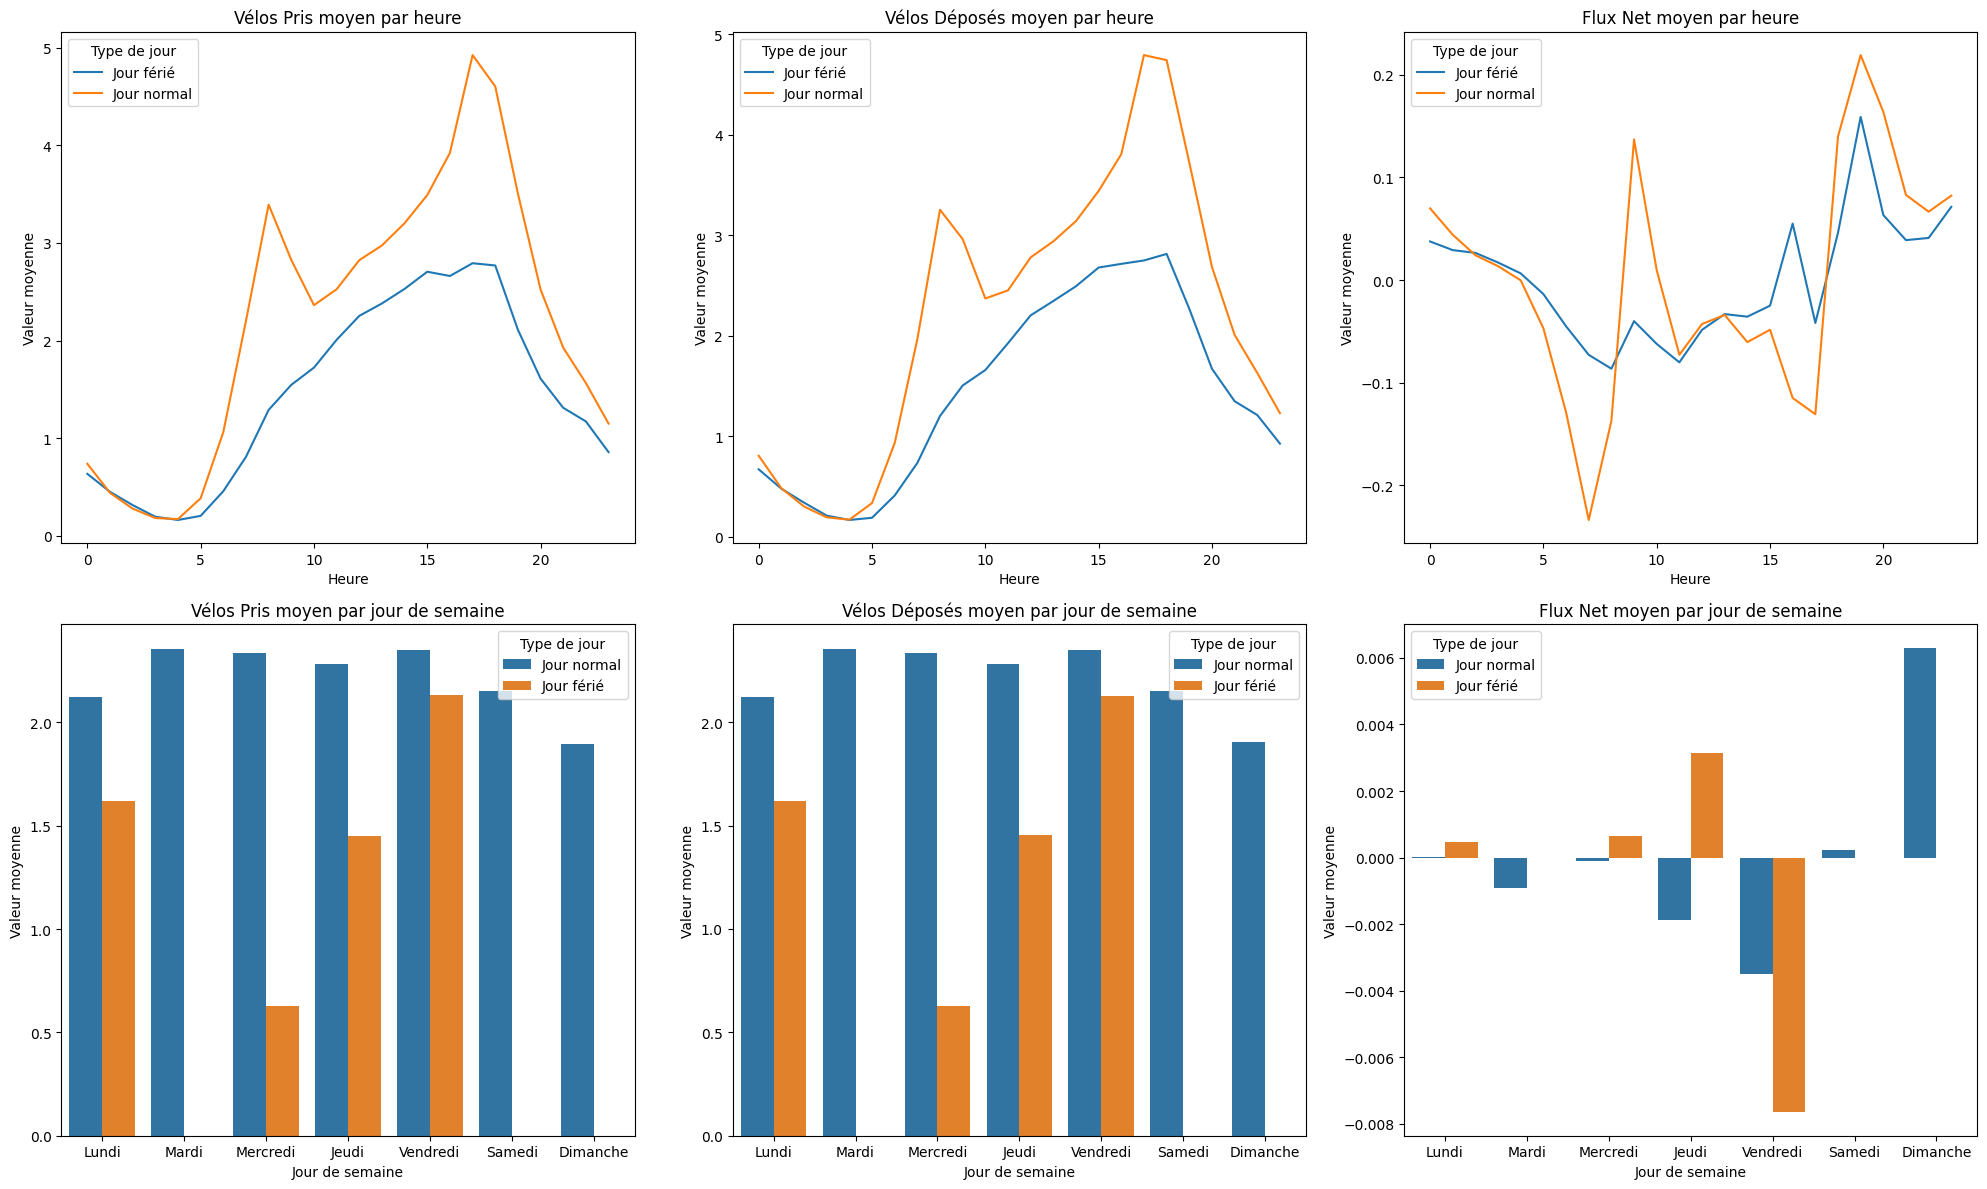

In [24]:
def comparer_flux_feries_par_heure_et_semaine(dataset):
    """
    Compare num_bikes_taken, num_bikes_dropped, net_flow
    between holidays and normal days, by hour and by day of the week.
    """
    dataset = dataset.copy()

    # Labels lisibles
    dataset["type_jour"] = dataset["is_holiday"].map({
        True: "Jour férié",
        False: "Jour normal"
    })

    # Par heure
    agg_heure = (
        dataset
        .groupby(["hour", "type_jour"])[["num_bikes_taken","num_bikes_dropped","net_flow"]]
        .mean()
        .reset_index()
    )

    # Par jour semaine
    agg_jour = (
        dataset
        .groupby(["jour_semaine","type_jour"], observed=True)[["num_bikes_taken","num_bikes_dropped","net_flow"]]
        .mean()
        .reset_index()
    )

    # Graph
    flux_cols = ["num_bikes_taken","num_bikes_dropped","net_flow"]
    flux_labels = ["Vélos Pris","Vélos Déposés","Flux Net"]

    fig, axes = plt.subplots(2, 3, figsize=(20,12))  # 2 rows (hour, weekday), 3 cols (flux types)

    # Par heure
    for i, col in enumerate(flux_cols):
        sns.lineplot(
            data=agg_heure, x="hour", y=col, hue="type_jour", ax=axes[0,i]
        )
        axes[0,i].set_title(f"{flux_labels[i]} moyen par heure")
        axes[0,i].set_xlabel("Heure")
        axes[0,i].set_ylabel("Valeur moyenne")
        axes[0,i].legend(title="Type de jour")

    # Par jour semaine
    ordre_jours = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']
    for i, col in enumerate(flux_cols):
        sns.barplot(
            data=agg_jour, x="jour_semaine", y=col, hue="type_jour",
            order=ordre_jours, ax=axes[1,i]
        )
        axes[1,i].set_title(f"{flux_labels[i]} moyen par jour de semaine")
        axes[1,i].set_xlabel("Jour de semaine")
        axes[1,i].set_ylabel("Valeur moyenne")
        axes[1,i].legend(title="Type de jour")

    plt.tight_layout()
    plt.show()

comparer_flux_feries_par_heure_et_semaine(dataset)

L'influence de la variable jour férié est très net sur plusieurs aspects:
- il n'y a plus de pics le matin. L'augementation de laprise et dépose se fait régulièrement tout au long de la journée jusqu'à 19h puis redescend 
- les jours fériés diminuent drastiquement l'utilisation des vélos lorsque celui-ci tombe en milieu de semaine. L'effet est moins notable autour du weekend (jeudi ou lundi). Si le jour férié tombe un vendredi, alors le nombre d'utilisation des vélos est presque comme un jour normal.


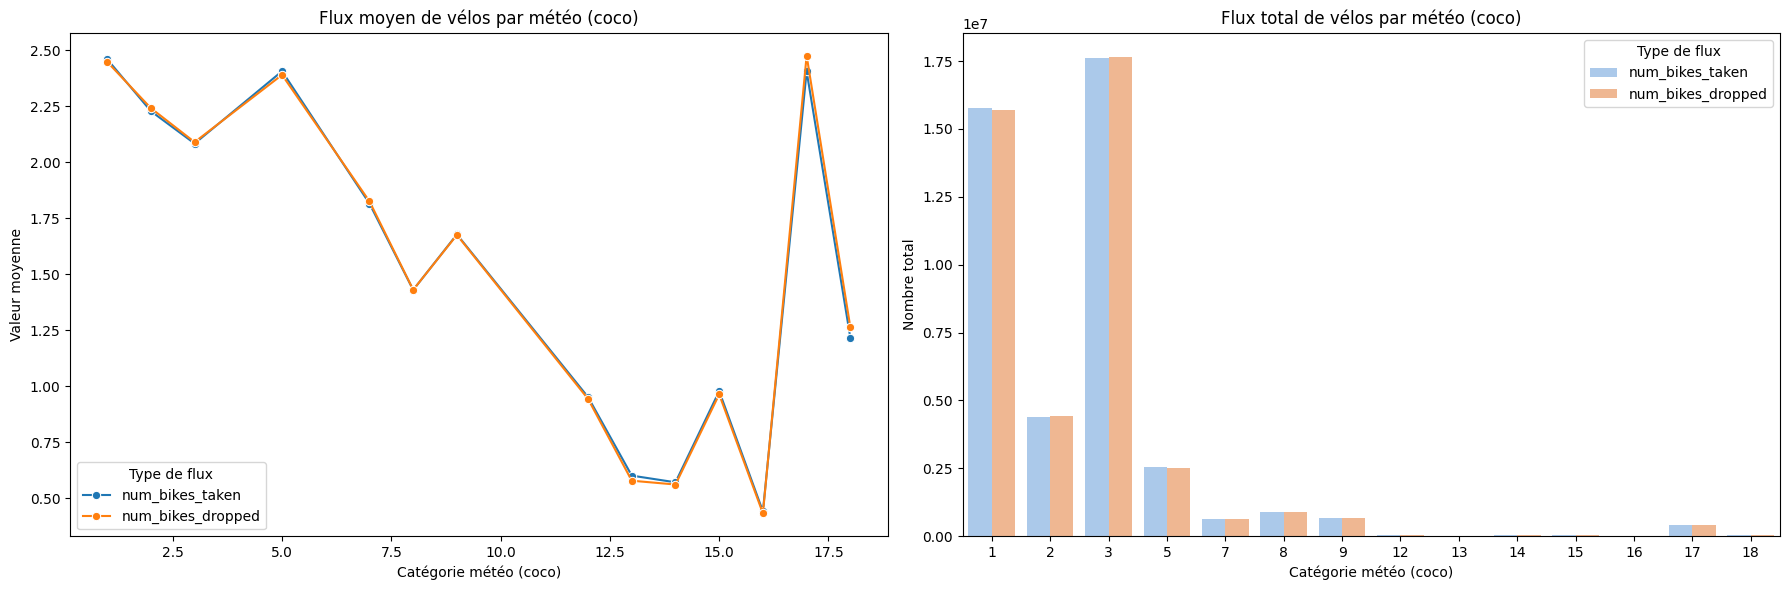

In [25]:
def comparer_flux_coco_moyenne_et_total(dataset):
    dataset = dataset.copy()

    # --- 1. Moyenne ---
    agg_coco_mean = (
        dataset
        .groupby("coco")[["num_bikes_taken", "num_bikes_dropped"]]
        .mean()
        .reset_index()
        .sort_values("coco")
    )
    agg_mean_long = agg_coco_mean.melt(
        id_vars="coco",
        value_vars=["num_bikes_taken", "num_bikes_dropped"],
        var_name="Type de flux",
        value_name="Valeur moyenne"
    )

    # --- 2. Total ---
    agg_coco_sum = (
        dataset
        .groupby("coco")[["num_bikes_taken", "num_bikes_dropped"]]
        .sum()
        .reset_index()
        .sort_values("coco")
    )
    agg_sum_long = agg_coco_sum.melt(
        id_vars="coco",
        value_vars=["num_bikes_taken", "num_bikes_dropped"],
        var_name="Type de flux",
        value_name="Nombre total"
    )

    # --- Graphiques côte à côte ---
    fig, axes = plt.subplots(1, 2, figsize=(18,6))

    # Moyenne
    sns.lineplot(data=agg_mean_long, x="coco", y="Valeur moyenne", hue="Type de flux", marker="o", ax=axes[0])
    axes[0].set_title("Flux moyen de vélos par météo (coco)")
    axes[0].set_xlabel("Catégorie météo (coco)")
    axes[0].set_ylabel("Valeur moyenne")
    axes[0].legend(title="Type de flux")

    # Total
    sns.barplot(data=agg_sum_long, x="coco", y="Nombre total", hue="Type de flux", palette="pastel", ax=axes[1])
    axes[1].set_title("Flux total de vélos par météo (coco)")
    axes[1].set_xlabel("Catégorie météo (coco)")
    axes[1].set_ylabel("Nombre total")
    axes[1].legend(title="Type de flux")

    plt.tight_layout()
    plt.show()

    return agg_coco_mean, agg_coco_sum

# --- Utilisation ---
agg_mean, agg_total = comparer_flux_coco_moyenne_et_total(dataset)

Regroupement les valeurs de coco pour simplifier l'analyse:
- pluie/neige groupe 8,9,10,11,12,13,14,15,16,18,19,20,21,22,23,24,25,26,27
- averse de pluie 17
- pas de pluie: 1,2,3,4,5,6

In [26]:
# Création de la colonne regroupée
dataset['coco_group'] = dataset['coco'].map({
    1: 'Pas de pluie', 2: 'Pas de pluie', 3: 'Pas de pluie',
    4: 'Pas de pluie', 5: 'Pas de pluie', 6: 'Pas de pluie',
    8: 'Pluie/Neige', 9: 'Pluie/Neige', 10: 'Pluie/Neige',
    11: 'Pluie/Neige', 12: 'Pluie/Neige', 13: 'Pluie/Neige',
    14: 'Pluie/Neige', 15: 'Pluie/Neige', 16: 'Pluie/Neige',
    18: 'Pluie/Neige', 19: 'Pluie/Neige', 20: 'Pluie/Neige',
    21: 'Pluie/Neige', 22: 'Pluie/Neige', 23: 'Pluie/Neige',
    24: 'Pluie/Neige', 25: 'Pluie/Neige', 26: 'Pluie/Neige',
    27: 'Pluie/Neige',
    17: 'Averse de pluie'
})

# Vérificationp
dataset['coco_group'].value_counts()


coco_group
Pas de pluie       17887144
Pluie/Neige         1275728
Averse de pluie      168450
Name: count, dtype: int64

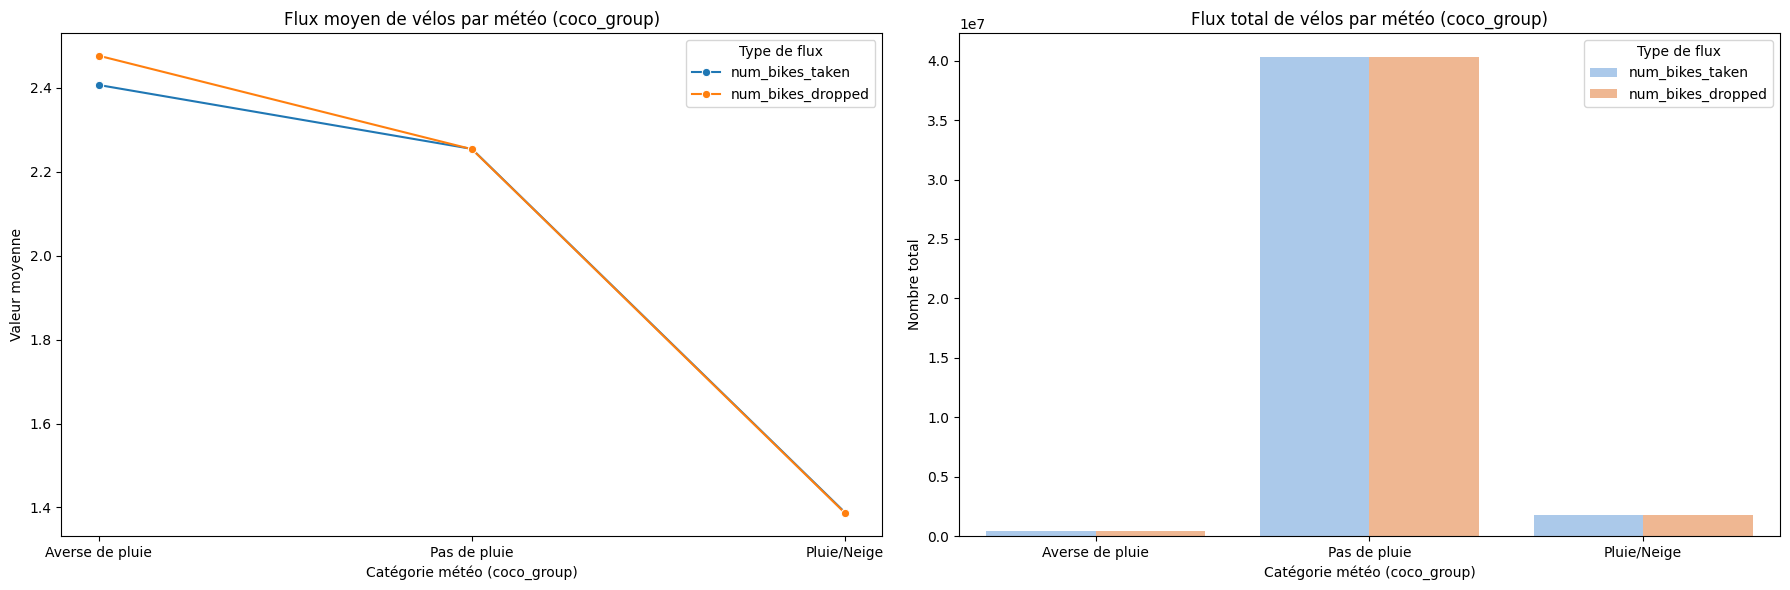

In [27]:
def comparer_flux_coco_moyenne_et_total(dataset):
    dataset = dataset.copy()

    # --- 1. Moyenne ---
    agg_coco_mean = (
        dataset
        .groupby("coco_group")[["num_bikes_taken", "num_bikes_dropped"]]
        .mean()
        .reset_index()
        .sort_values("coco_group")
    )
    agg_mean_long = agg_coco_mean.melt(
        id_vars="coco_group",
        value_vars=["num_bikes_taken", "num_bikes_dropped"],
        var_name="Type de flux",
        value_name="Valeur moyenne"
    )

    # --- 2. Total ---
    agg_coco_sum = (
        dataset
        .groupby("coco_group")[["num_bikes_taken", "num_bikes_dropped"]]
        .sum()
        .reset_index()
        .sort_values("coco_group")
    )
    agg_sum_long = agg_coco_sum.melt(
        id_vars="coco_group",
        value_vars=["num_bikes_taken", "num_bikes_dropped"],
        var_name="Type de flux",
        value_name="Nombre total"
    )

    # --- Graphiques côte à côte ---
    fig, axes = plt.subplots(1, 2, figsize=(18,6))

    # Moyenne
    sns.lineplot(data=agg_mean_long, x="coco_group", y="Valeur moyenne", hue="Type de flux", marker="o", ax=axes[0])
    axes[0].set_title("Flux moyen de vélos par météo (coco_group)")
    axes[0].set_xlabel("Catégorie météo (coco_group)")
    axes[0].set_ylabel("Valeur moyenne")
    axes[0].legend(title="Type de flux")

    # Total
    sns.barplot(data=agg_sum_long, x="coco_group", y="Nombre total", hue="Type de flux", palette="pastel", ax=axes[1])
    axes[1].set_title("Flux total de vélos par météo (coco_group)")
    axes[1].set_xlabel("Catégorie météo (coco_group)")
    axes[1].set_ylabel("Nombre total")
    axes[1].legend(title="Type de flux")

    plt.tight_layout()
    plt.show()

    return agg_coco_mean, agg_coco_sum

# --- Utilisation ---
agg_mean, agg_total = comparer_flux_coco_moyenne_et_total(dataset)

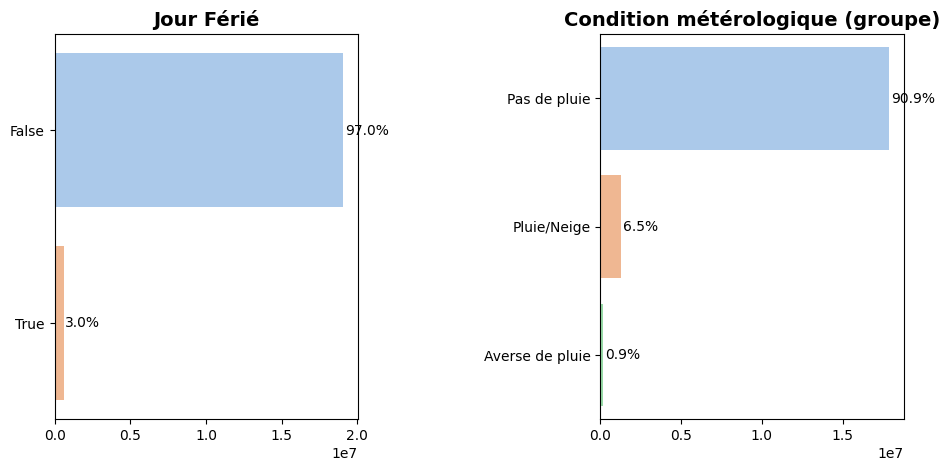

In [28]:
# Visualisation des distributions des variables catégorielles avec des barplots
# Dictionnaire titres
titles_dict_cat = {
    "is_holiday": "Jour Férié",
    "coco_group": "Condition métérologique (groupe)",
}

col_categorical = ['is_holiday', 'coco_group']

n_cols = 3
n_rows = len(col_categorical) // n_cols + (len(col_categorical) % n_cols > 0)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*5))
fig.subplots_adjust(hspace=0.9, wspace=0.8)
axes = axes.flatten()

for i, col in enumerate(col_categorical):
    ax = axes[i]

    # Countplot horizontal
    sns.countplot(
        y=col,
        data=dataset,
        ax=ax,
        hue=col,       # nécessaire pour palette
        palette='pastel',
        order=dataset[col].value_counts().index,
        dodge=False,   # empile toutes les barres
        legend=False
    )

    # Supprimer labels axes
    ax.set_xlabel('')
    ax.set_ylabel('')

    # Titre
    ax.set_title(titles_dict_cat[col], fontsize=14, fontweight='bold')

    # Ajouter pourcentages sur chaque barre
    total = len(dataset)
    for p in ax.patches:
        width = p.get_width()
        percentage = width / total * 100
        ax.text(width + total*0.005,  # un petit décalage
                p.get_y() + p.get_height()/2,
                f'{percentage:.1f}%',
                va='center')

# Supprimer axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

### Analyse bivariée et multivariée

Relation entre variables :

- Scatter plots
- Heatmaps de corrélation
- Pairplots

Identifier relations, dépendances, patterns

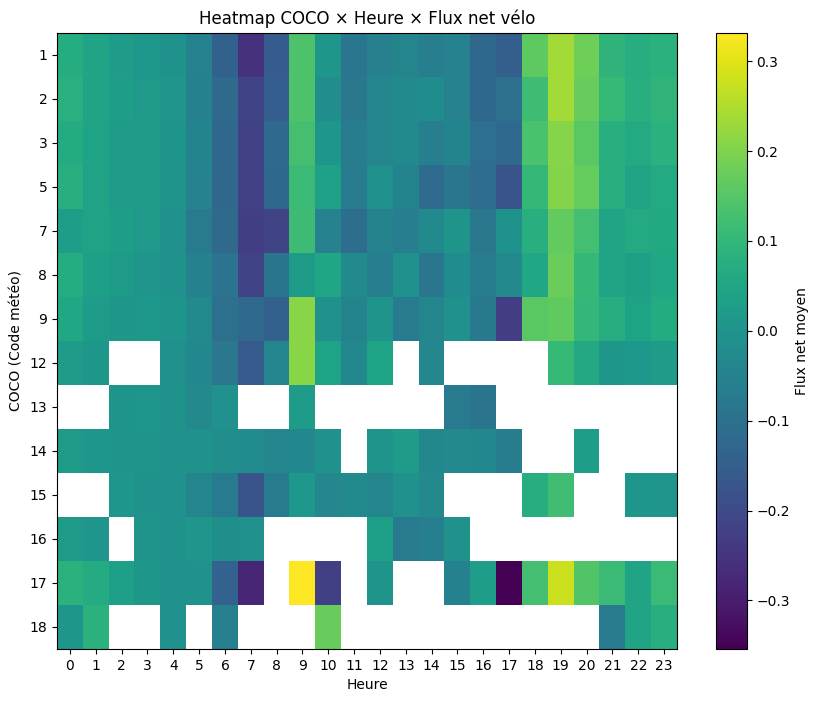

In [29]:
# Agrégation moyenne du flux net par coco et heure
heatmap_data = (
    dataset
    .groupby(["coco", "hour"])["net_flow"]
    .mean()
    .reset_index()
    .pivot(index="coco", columns="hour", values="net_flow")
)

# Création du graphique heatmap
plt.figure(figsize=(10,8))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Flux net moyen")

plt.xlabel("Heure")
plt.ylabel("COCO (Code météo)")
plt.title("Heatmap COCO × Heure × Flux net vélo")

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

plt.show()

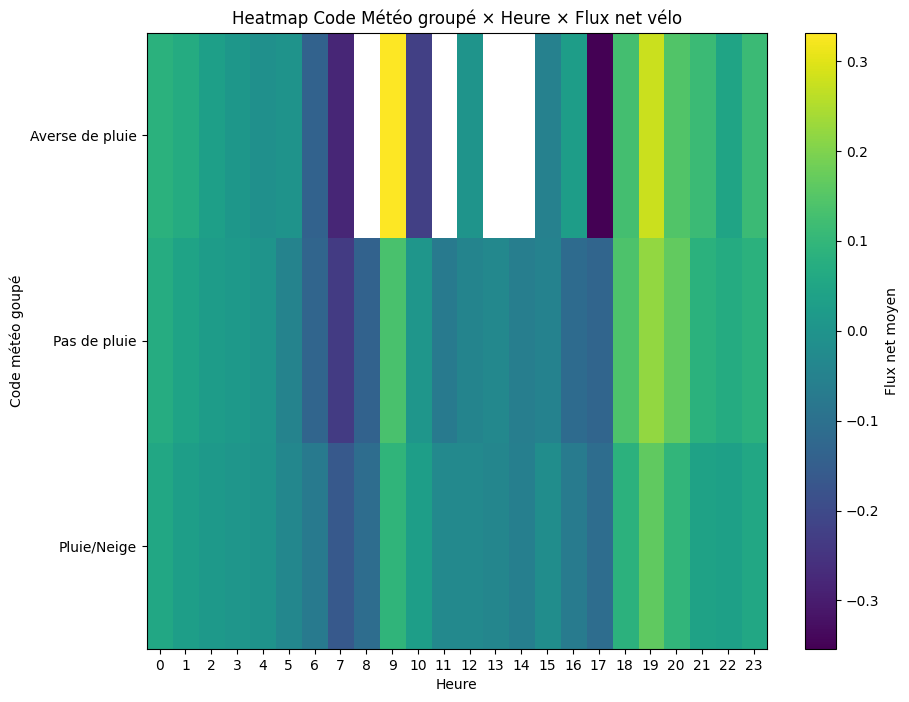

In [30]:
# Agrégation moyenne du flux net par coco et heure
heatmap_data = (
    dataset
    .groupby(["coco_group", "hour"])["net_flow"]
    .mean()
    .reset_index()
    .pivot(index="coco_group", columns="hour", values="net_flow")
)

# Création du graphique heatmap
plt.figure(figsize=(10,8))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Flux net moyen")

plt.xlabel("Heure")
plt.ylabel("Code météo goupé")
plt.title("Heatmap Code Météo groupé × Heure × Flux net vélo")

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

plt.show()

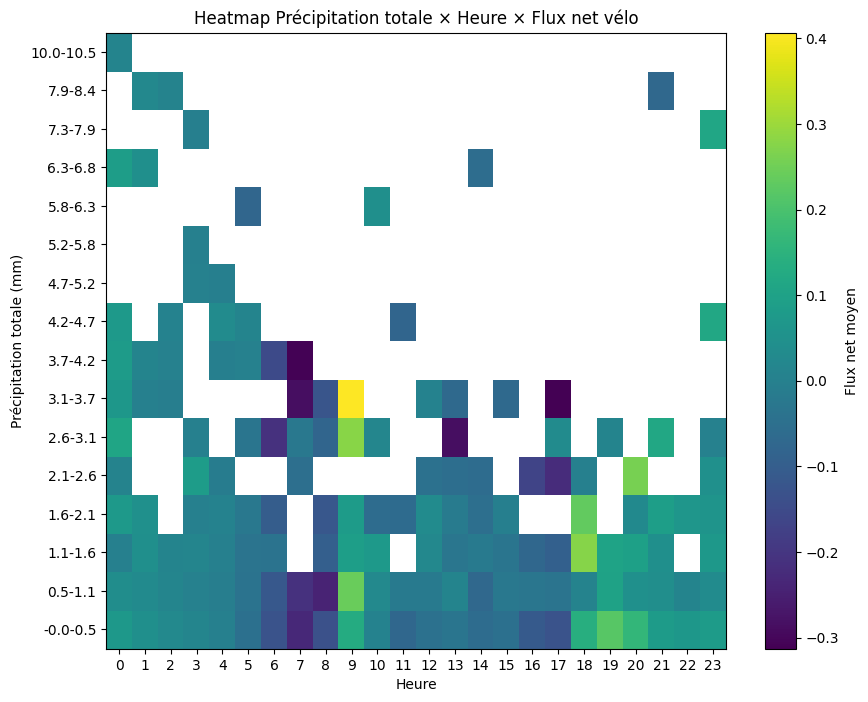

In [31]:
# Arrondir la température pour éviter trop de lignes
dataset["precipitation_total_round"] = dataset["precipitation_total"].round(1)

# Créer des bins pour la température
dataset["precipitation_total_bin"] = pd.cut(dataset["precipitation_total_round"], bins=20)

# Agrégation flux net moyen par bin de température et heure
heatmap_data = (
    dataset
    .groupby(["precipitation_total_bin", "hour"], observed=True)["net_flow"]
    .mean()
    .reset_index()
    .pivot(index="precipitation_total_bin", columns="hour", values="net_flow")
)

# Graphique
plt.figure(figsize=(10,8))
plt.imshow(heatmap_data, aspect="auto", origin="lower")
plt.colorbar(label="Flux net moyen")

plt.xlabel("Heure")
plt.ylabel("Précipitation totale (mm)")
plt.title("Heatmap Précipitation totale × Heure × Flux net vélo")

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), [f"{interval.left:.1f}-{interval.right:.1f}" for interval in heatmap_data.index])

plt.show()

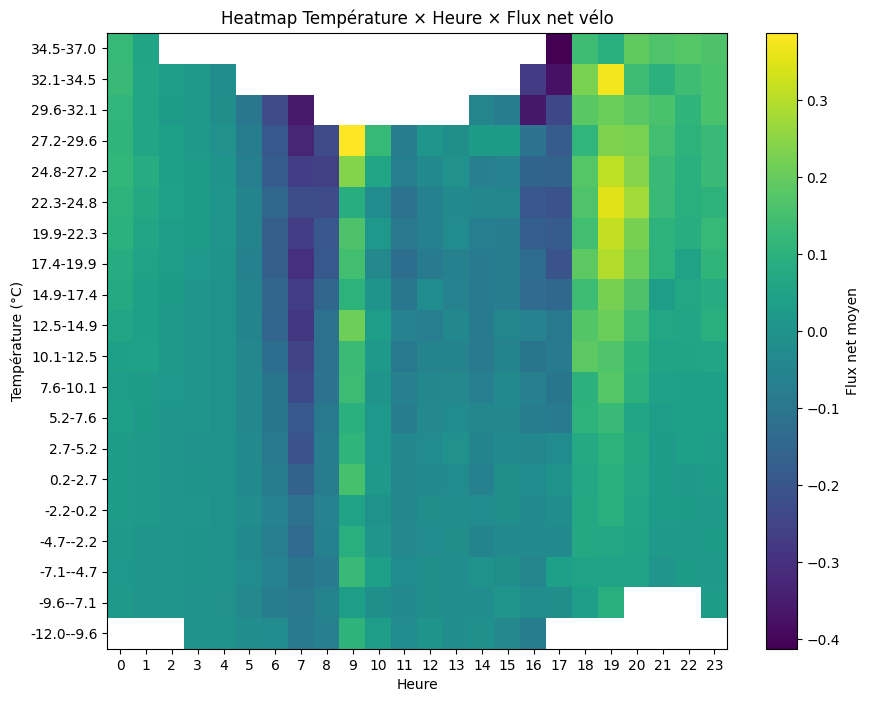

In [32]:
# Arrondir la température pour éviter trop de lignes
dataset["temp_round"] = dataset["temp"].round(1)

# Créer des bins pour la température
dataset["temp_bin"] = pd.cut(dataset["temp_round"], bins=20)

# Agrégation flux net moyen par bin de température et heure
heatmap_data = (
    dataset
    .groupby(["temp_bin", "hour"], observed=True)["net_flow"]
    .mean()
    .reset_index()
    .pivot(index="temp_bin", columns="hour", values="net_flow")
)

# Graphique
plt.figure(figsize=(10,8))
plt.imshow(heatmap_data, aspect="auto", origin="lower")
plt.colorbar(label="Flux net moyen")

plt.xlabel("Heure")
plt.ylabel("Température (°C)")
plt.title("Heatmap Température × Heure × Flux net vélo")

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), [f"{interval.left:.1f}-{interval.right:.1f}" for interval in heatmap_data.index])

plt.show()

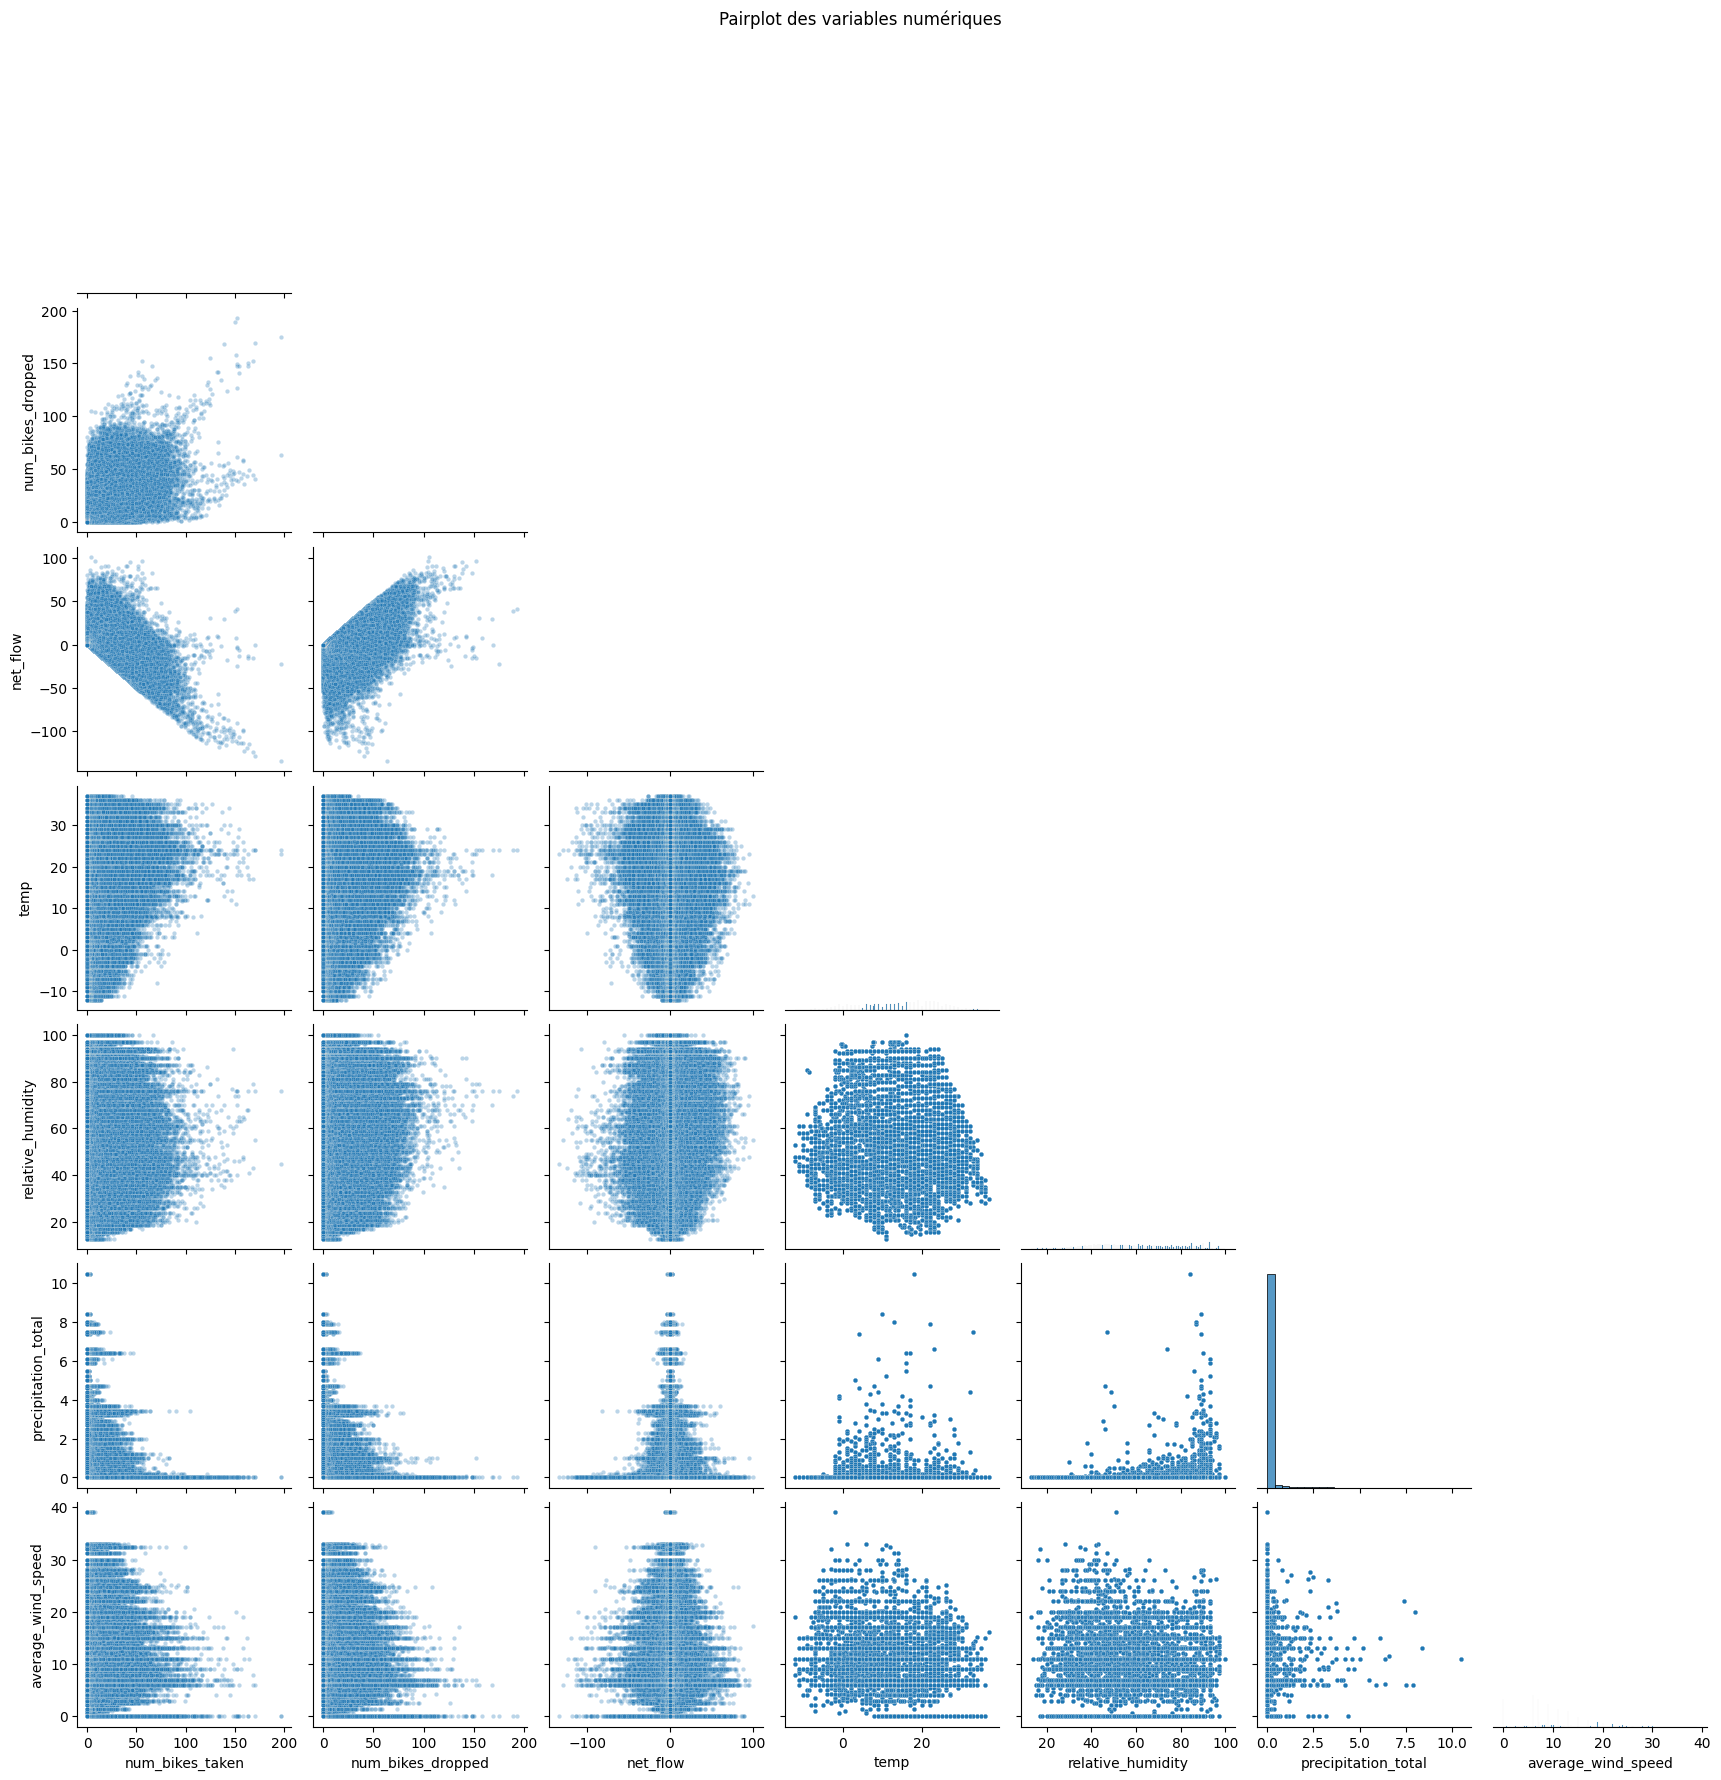

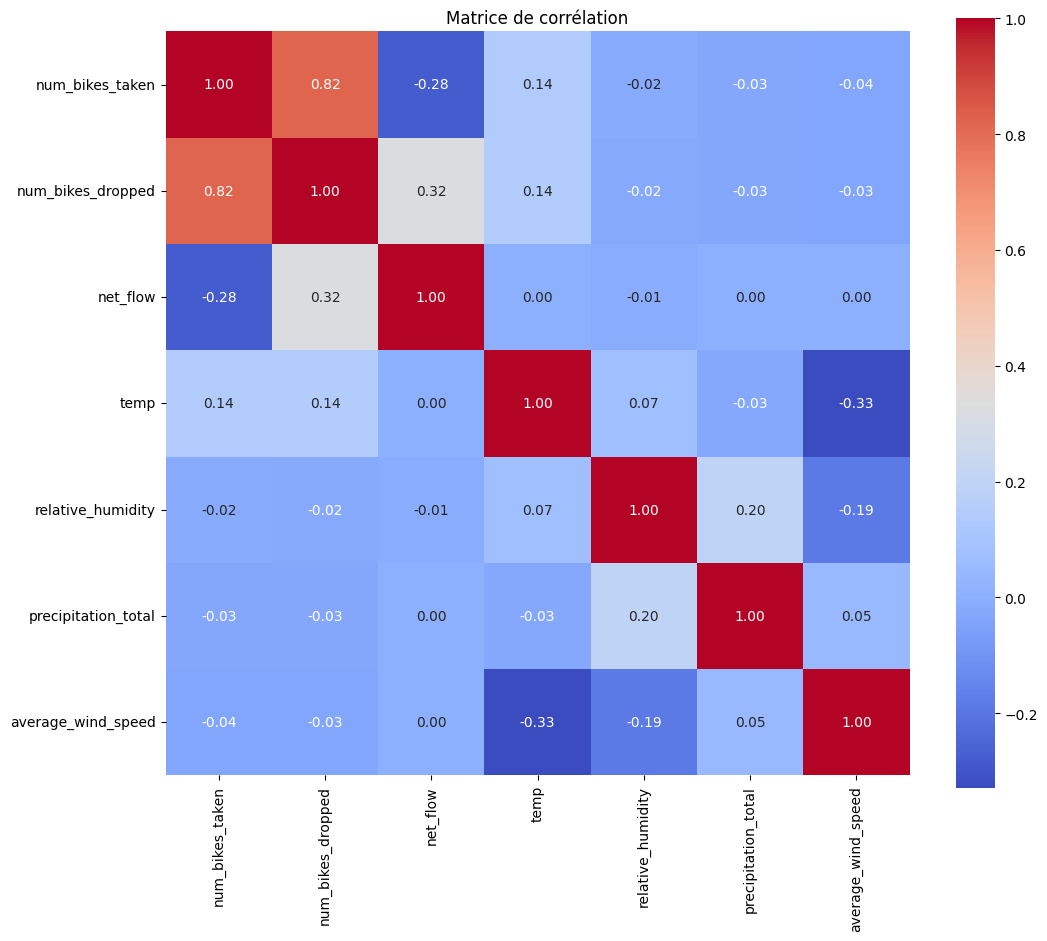

In [33]:
# Select only numerical columns for correlation/pairplots
numerical_cols = [
    'num_bikes_taken', 'num_bikes_dropped', 'net_flow',
    'temp', 'relative_humidity', 'precipitation_total',
    'average_wind_speed'
]

# --- 1. Pairplot ---
sns.pairplot(dataset[numerical_cols], corner=True, kind='scatter', plot_kws={'alpha':0.3, 's':10})
plt.suptitle("Pairplot des variables numériques", y=1.02)
plt.show()

# --- 2. Correlation matrix ---
corr_matrix = dataset[numerical_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matrice de corrélation")
plt.show()

Corrélation apparente uniquemententre le nombre de vélo pris et déposés.

## Seulement sur les tops top_taken_dropped

Nombre de lignes : 175200
Nombre de stations : 20


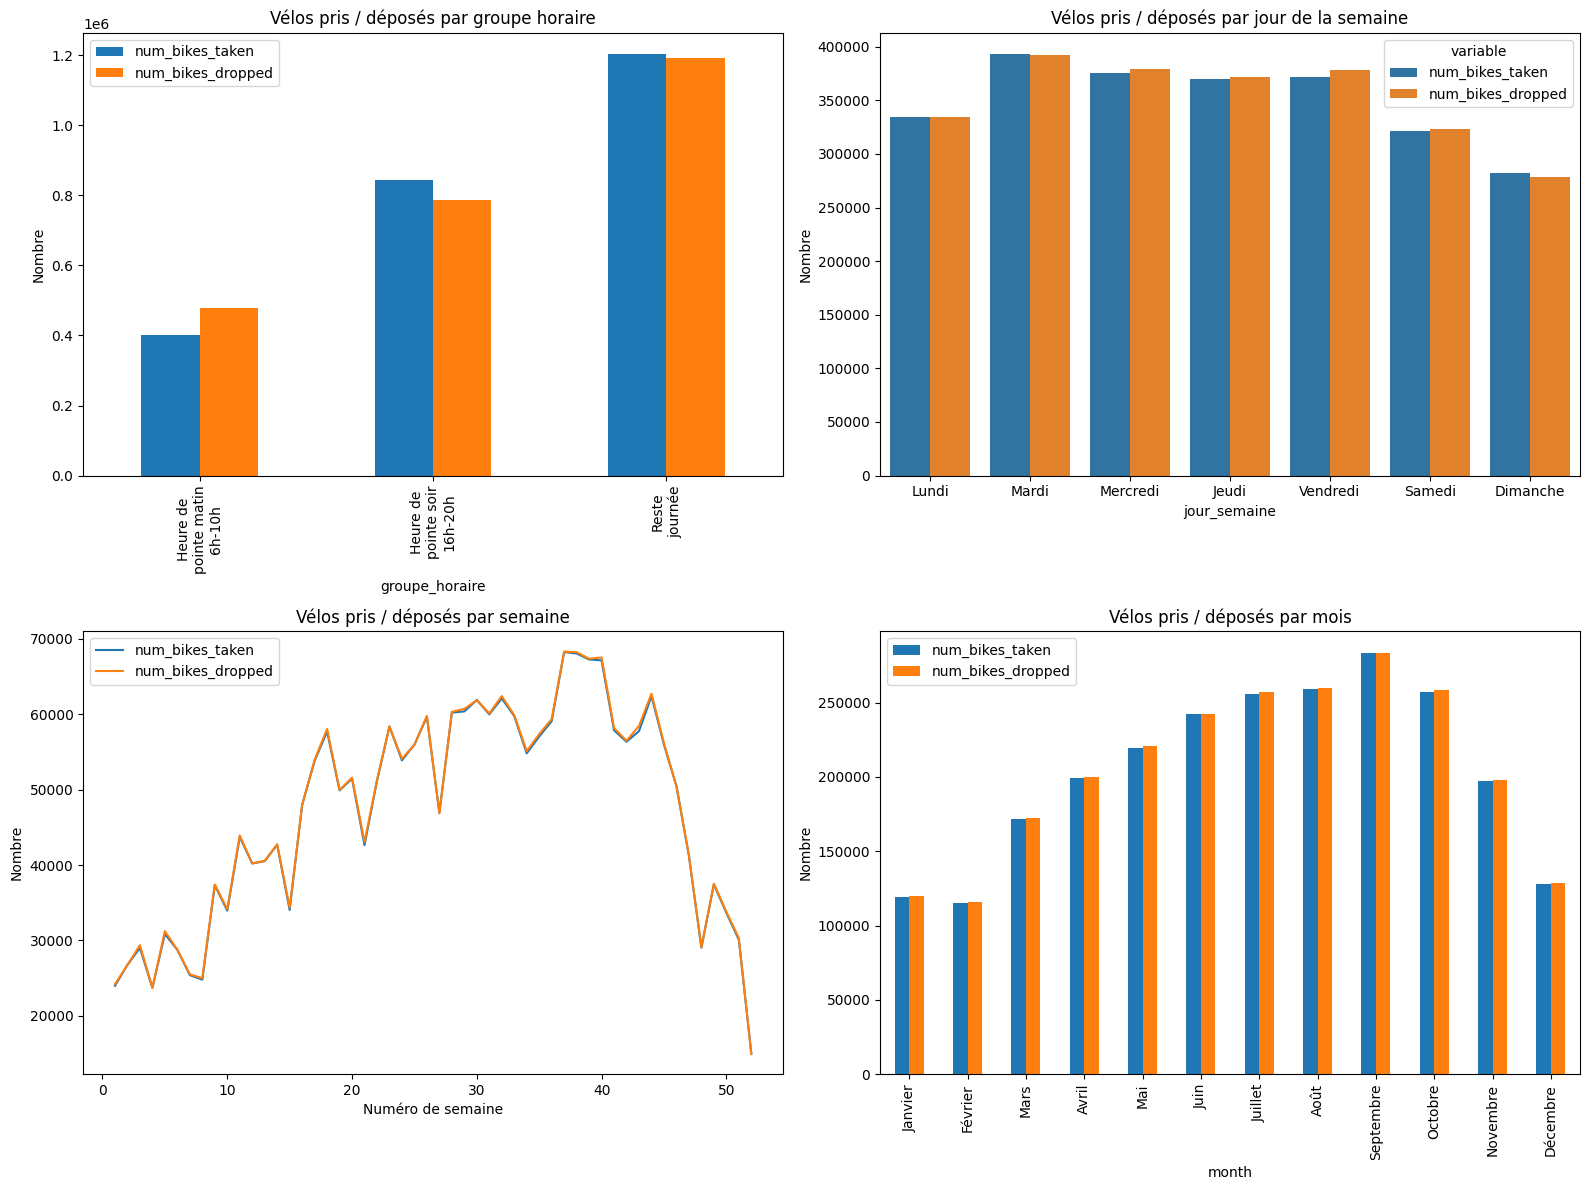

In [34]:
# S'assurer que les types correspondent
dataset['station_id'] = dataset['station_id'].astype(str)
station_list = [str(s) for s in top_taken_dropped]

# Filtrage
dataset_filtered = dataset[dataset['station_id'].isin(station_list)].copy()

# Vérification
print("Nombre de lignes :", len(dataset_filtered))
print("Nombre de stations :", dataset_filtered['station_id'].nunique())

tracer_flux_velos(dataset_filtered)

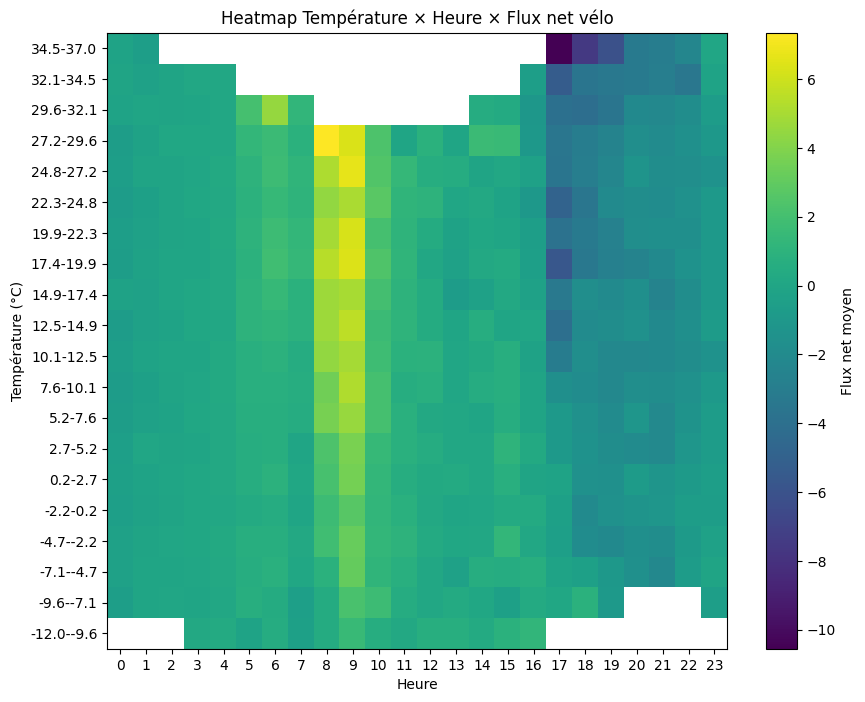

In [35]:
# Agrégation flux net moyen par bin de température et heure
heatmap_data = (
    dataset_filtered
    .groupby(["temp_bin", "hour"], observed=True)["net_flow"]
    .mean()
    .reset_index()
    .pivot(index="temp_bin", columns="hour", values="net_flow")
)

# Graphique
plt.figure(figsize=(10,8))
plt.imshow(heatmap_data, aspect="auto", origin="lower")
plt.colorbar(label="Flux net moyen")

plt.xlabel("Heure")
plt.ylabel("Température (°C)")
plt.title("Heatmap Température × Heure × Flux net vélo")

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), [f"{interval.left:.1f}-{interval.right:.1f}" for interval in heatmap_data.index])

plt.show()

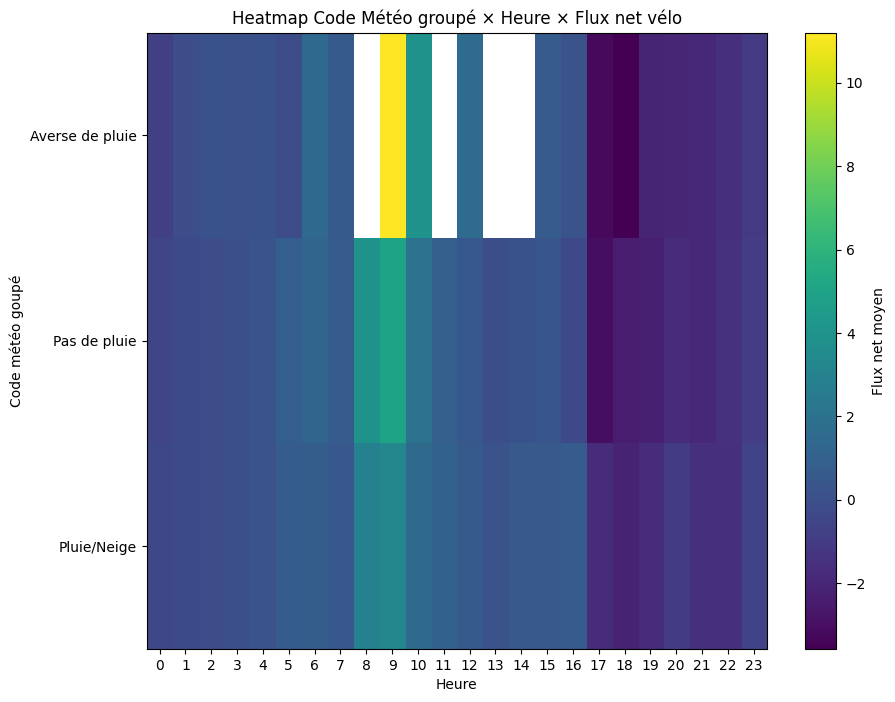

In [36]:
# Agrégation moyenne du flux net par coco et heure
heatmap_data = (
    dataset_filtered
    .groupby(["coco_group", "hour"])["net_flow"]
    .mean()
    .reset_index()
    .pivot(index="coco_group", columns="hour", values="net_flow")
)

# Création du graphique heatmap
plt.figure(figsize=(10,8))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Flux net moyen")

plt.xlabel("Heure")
plt.ylabel("Code météo goupé")
plt.title("Heatmap Code Météo groupé × Heure × Flux net vélo")

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

plt.show()

### Résumé

#### Données utilisées

Le dataset contient les flux de vélos par station et par heure, enrichi avec des données météo et calendaires.

**Variables disponibles :**

| Catégorie | Variables |
|---|---|
| Identifiant | `station_id` |
| Temporel | `date`, `year`, `month`, `day`, `hour`, `jour_semaine` |
| Flux vélos | `num_bikes_taken`, `num_bikes_dropped`, `net_flow` |
| Météo | `temp`, `relative_humidity`, `precipitation_total`, `average_wind_speed`, `coco` |
| Calendaire | `is_holiday` |

**Variable cible :** `net_flow` = vélos déposés − vélos pris (par station, par heure)

---

- Fortes disparités sur le flux net entre stations — variance importante

---

#### Statistiques descriptives

Les variables météorologiques (température, humidité, vent) sont dans des amplitudes cohérentes avec NYC. Les précipitations sont concentrées sur de faibles valeurs — la grande majorité des heures observées sont sans pluie.

Les variables de flux vélos (`num_bikes_taken`, `num_bikes_dropped`, `net_flow`) présentent une **forte variabilité inter-stations** et une **forte asymétrie** dans les distributions, avec des pics aux heures de pointe.

---

#### Analyse univariée

##### Vélos et flux
- Grosses disparités entre stations sur le nombre de vélos pris, déposés et le flux net
- Les distributions sont fortement asymétriques à droite — quelques stations concentrent l'essentiel du flux

##### Météo
- Les précipitations sont peu représentées : seulement **3,1 % des observations** correspondent à de la pluie (`coco = 8`)
- La variable `coco` (code météo) a été **regroupée en 3 catégories** pour simplifier l'analyse :
  - **Pas de pluie** : ciel dégagé, nuageux, brouillard (codes 1–6)
  - **Averse** : averses de pluie (code 17)
  - **Pluie/Neige** : pluie, neige, grêle (codes 8–16, 18–27)

---

#### Analyse par station

Le dataset contient un **grand nombre de stations uniques**. L'analyse a été focalisée sur les stations les plus actives, identifiées selon trois critères :

- Top 20 stations avec le plus de **vélos pris**
- Top 20 stations avec le plus de **vélos déposés**
- Top 20 stations avec le **flux net le plus positif** (plus de prises que de dépôts)
- Top 20 stations avec le **flux net le plus négatif** (plus de dépôts que de prises)

→ Une sélection des **stations présentes à la fois dans le top vélos pris et déposés** (`top_taken_dropped`) a été retenue pour les analyses approfondies et l'export final.

---

#### Analyse temporelle

##### Effet de l'heure de la journée
- Deux **pics de flux nets** bien identifiés : heure de pointe matin (6h–10h) et soir (16h–20h)
- En dehors des heures de pointe, le flux est plus faible et plus stable

##### Effet du jour de la semaine
- Le jour de la semaine **n'influence pas significativement** le nombre de vélos utilisés en semaine
- En revanche, les **week-ends** montrent un profil différent : pas de pics le matin, usage plus étalé dans la journée

##### Effet du mois / saisonnalité
- Utilisation clairement **saisonnière** :
  - **Pic estival** : mai, juin, juillet, août, septembre, octobre
  - **Creux hivernal** : décembre, janvier, février

##### Effet des jours fériés
L'impact est **très net** sur plusieurs dimensions :
- Plus de pics le matin — l'augmentation des prises et dépôts se fait progressivement tout au long de la journée jusqu'à 19h
- Les jours fériés **réduisent drastiquement** l'utilisation globale
- Le profil ressemble davantage à un samedi qu'à un jour de semaine normal

---

### Effet de la météo sur le flux

##### Condition météo (`coco_group`) × heure
- Par temps de pluie/neige, le flux net est **systématiquement plus faible** quelle que soit l'heure
- L'effet est plus prononcé aux heures de pointe

##### Température × heure
- La température est **positivement corrélée** avec l'utilisation : plus il fait chaud, plus le flux augmente
- Cet effet est cohérent avec la saisonnalité observée

##### Précipitations
- Peu de données sous la pluie (3,1 %), mais l'effet est visible : la pluie **réduit les flux**
- Interrogation levée dans le notebook : est-il pertinent d'utiliser `coco` seul, ou vaut-il mieux se concentrer sur la **température et l'humidité** comme proxies météo ?

---

### Analyse multivariée

- **Matrice de corrélation** : la seule corrélation forte et évidente est entre `num_bikes_taken` et `num_bikes_dropped` — ce qui est logique (les stations très fréquentées voient beaucoup de prises et de dépôts)
- Les variables météo ont une **corrélation modérée** avec le flux net
- Pas de multicolinéarité problématique entre les variables météo elles-mêmes

---

## 9. Décisions prises suite à l'EDA

| Décision | Justification |
|---|---|
| Créer la variable `coco_group` (3 modalités) | Simplification de `coco` (27 codes → 3 groupes) pour réduire le bruit |
| Conserver `is_holiday` | Impact très net sur les patterns horaires et le volume global |
| Conserver `temp` et `relative_humidity` | Corrélées avec le flux, peu redondantes |
| Sélection Top 20 stations (`top_taken_dropped`) | Focalisation sur les stations les plus représentatives pour le modèle |
| Export du dataset filtré en parquet | Base pour l'entraînement du modèle (`03_Model/`) |


### Export données

In [ ]:
dataset_export = dataset.copy()

# Marteau: convertir object + category en string (compat parquet max)
for c in dataset_export.columns:
    dtype = dataset_export[c].dtype
    if isinstance(dtype, pd.CategoricalDtype) or pd.api.types.is_object_dtype(dtype):
        dataset_export[c] = dataset_export[c].astype(str)

# Datetimes sûrs
for c in ["date", "date_hour"]:
    if c in dataset_export.columns:
        dataset_export[c] = pd.to_datetime(dataset_export[c], errors="coerce")

# Export
PATH = "../01_Data/"
TOP20_FILE = PATH + "dataset_export.parquet"

if TOP20_FILE in os.listdir():
        os.remove(TOP20_FILE)
dataset_export.to_parquet(TOP20_FILE, index=False, compression="snappy")


In [ ]:
# Top20
top20_stations = (
    dataset.groupby("station_id", observed=True)["net_flow"]
    .sum().sort_values(ascending=False).head(20).index
)


dataset_top20 = dataset[dataset["station_id"].isin(top_taken_dropped)].copy()

# Marteau: convertir object + category en string (compat parquet max)
for c in dataset_top20.columns:
    dtype = dataset_top20[c].dtype
    if isinstance(dtype, pd.CategoricalDtype) or pd.api.types.is_object_dtype(dtype):
        dataset_top20[c] = dataset_top20[c].astype(str)

# Datetimes sûrs
for c in ["date", "date_hour"]:
    if c in dataset_top20.columns:
        dataset_top20[c] = pd.to_datetime(dataset_top20[c], errors="coerce")

# Export
PATH = "../01_Data/"
TOP20_FILE = PATH + "dataset_top20_stations.parquet"

if TOP20_FILE in os.listdir():
        os.remove(TOP20_FILE)
dataset_top20.to_parquet(TOP20_FILE, index=False, compression="snappy")

# Save station_list as a simple text file (one per line)\n",
TOP20_STATION_LIST = PATH +'top20_station_list.csv'
if TOP20_STATION_LIST in os.listdir():
    os.remove(TOP20_STATION_LIST)
    
with open(TOP20_STATION_LIST, "w", encoding="utf-8") as f:
    for station in top_taken_dropped:
        f.write(f"{station}\n")

print("Saved:", TOP20_FILE)
print("Saved:", TOP20_STATION_LIST)

# Save station_list as a simple text file (one per line)\n",
TOP20_STATION_LIST = PATH +'top20_station_list.csv'
if TOP20_STATION_LIST in os.listdir():
    os.remove(TOP20_STATION_LIST)
    
with open(TOP20_STATION_LIST, "w", encoding="utf-8") as f:
    for station in top_taken_dropped:
        f.write(f"{station}\n")

print("Saved:", TOP20_STATION_LIST)